# Estimación de la degradación relativa del rendimiento en carrera de Fórmula 1

## Introducción

Se han desarrollado y evaluado distintos modelos predictivos para predecir el rendimiento relativo de pilotos de Fórmula 1 a partir de un dataset de carrera. El objetivo es estimar la degradación relativa del rendimiento de un piloto durante una carrera mediante técnicas de machine learning. 

Se define la variable a predecir, denominada LapDelta, calculada como la diferencia entre el tiempo de cada vuelta y la mejor vuelta realizada por un piloto concreto dentro del mismo gran premio. Con esta variable se puede estudiar la evolución del rendimiento del piloto en cada carrera, reduciendo parte del efecto asociado a las diferencias entre circuitos y pilotos y facilitando así la comparación entre carreras. Al utilizar como referencia la mejor vuelta del piloto dentro del mismo gran premio, el enfoque tiene un carácter retrospectivo, ya que se analiza el rendimiento relativo una vez conocida la evolución completa de la carrera, pero no supone una predicción en tiempo real del tiempo de vuelta futuro.

Para construir los modelos se aplican técnicas de limpieza y preprocesamiento de datos, creación de nuevas variables y entrenamiento de distintos algoritmos supervisados de regresión. Los modelos se evalúan dejando fuera del entrenamiento un gran premio completo en cada evaluación, con el fin de analizar su capacidad de generalización.

## Descripción del Dataset

Para el desarrollo del trabajo se ha utilizado como base el dataset Formula 1: Race Data and Telemetry, disponible en la plataforma kaggle y diseñado para el análisis de métricas de rendimiento de pilotos y vehículos. 

El dataset incluye datos recopilados y preprocesados a partir de APIs FastF1 y Ergast, lo que ofrece información sobre el rendimiento del piloto en diferentes grandes premios y escenarios de carrera. Contiene información correspondiente a la temporada 2024 de Fórmula 1. Cuenta con 21 archivos en formato CSV, uno por cada gran premio disputado desde Baréin hasta São Paulo. Para completar la temporada se incorporan mediante FastF1 los datos de los grandes premios de Las Vegas, Catar y Abu Dabi, manteniendo la misma estructura que los archivos originales. De esta forma, se dispone finalmente de 24 archivos CSV correspondientes a los grandes premios de la temporada.

El conjunto de datos está estructurado para facilitar actualizaciones dinámicas, de manera que se puede realizar análisis avanzados como la optimización de estrategia de carrera, comparaciones de rendimiento y aplicaciones de machine learning. 

Además de los archivos de vueltas, se utilizan las tablas GP.csv y pilotos.csv. La primera contiene información sobre los grandes premios, como su nombre, localización, país y fecha. La segunda contiene los nombres completos de los pilotos, así como su número y abreviatura oficial.

## Importación de librerías
En primer lugar, se importan las librerías necesarias para la carga, tratamiento y análisis inicial de los datos. 

In [1]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

import os
import glob
import fastf1

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

import sys
from importlib.metadata import PackageNotFoundError, version

## Carga del dataset
El dataset se encuentra organizado en archivos diferentes para cada gran premio. Por ello, se realiza la carga conjunta de todos los archivos con el objetivo de obtener una única base de datos que sirva como punto de partida para el desarrollo del estudio.

También se cargan las tablas GP.csv y pilotos.csv, para poder relacionar la información de los grandes premios, así como la abreviatura de cada piloto con su nombre completo para mejorar la interpretación y presentación de los resultados.

Durante este proceso se incorpora la variable GP_file, obtenida a partir del nombre de cada archivo para identificar el gran premio al que pertenece cada vuelta.

Todos los archivos se concatenan en un único dataframe denominado df_master, que servirá como base para la posterior selección y limpieza de datos y la creación de nuevas variables.


In [2]:
#Incorporación de las tres carreras faltantes

os.makedirs("LapData", exist_ok=True)
os.makedirs("fastf1_cache", exist_ok=True)
fastf1.Cache.enable_cache("fastf1_cache")

rondas_faltantes = [22, 23, 24]
columnas_vueltas = ["DriverNumber", "Driver", "LapNumber", "Compound", "TyreLife", "Sector1Time", "Sector2Time", "Sector3Time", "LapTime"]
columnas_tiempo = ["Sector1Time", "Sector2Time", "Sector3Time", "LapTime"]

nuevos_gp, nuevos_pilotos, archivos_creados = [], [], []

for ronda in rondas_faltantes:
    print(f"\nCargando ronda {ronda}...")
    sesion = fastf1.get_session(2024, ronda, "R")
    sesion.load(laps=True, telemetry=False, weather=False, messages=False)
    nombre_gp = str(sesion.event["EventName"])

    vueltas = sesion.laps[columnas_vueltas].copy()

    for columna in columnas_tiempo:
        vueltas[columna] = vueltas[columna].dt.total_seconds()

    vueltas["DriverNumber"] = pd.to_numeric(vueltas["DriverNumber"], errors="coerce").astype("Int64")

    nombre_archivo = nombre_gp.replace(" ", "_") + ".csv"
    ruta_archivo = os.path.join("LapData", nombre_archivo)
    vueltas.to_csv(ruta_archivo, index=False)
    archivos_creados.append(ruta_archivo)

    print(f"{nombre_gp}: {len(vueltas)} vueltas guardadas")

    nuevos_gp.append({
        "Name": nombre_gp,
        "Year": 2024,
        "Location": sesion.event["Location"],
        "Country": sesion.event["Country"],
        "EventDate": pd.to_datetime(sesion.event["EventDate"]).date().isoformat()
    })

    resultados = pd.DataFrame(sesion.results).copy()

    if "DriverNumber" not in resultados.columns:
        resultados["DriverNumber"] = resultados.index.astype(str)

    nuevos_pilotos.append(resultados[["DriverNumber", "FullName", "Abbreviation"]].copy())


#Actualización de GP.csv

df_gp_original = pd.read_csv("Data/GP.csv")
df_gp_actualizado = pd.concat([df_gp_original.drop(columns=["ID"]), pd.DataFrame(nuevos_gp)], ignore_index=True)
df_gp_actualizado = df_gp_actualizado.drop_duplicates(subset=["Name", "Year"], keep="last")
df_gp_actualizado["EventDate"] = pd.to_datetime(df_gp_actualizado["EventDate"])
df_gp_actualizado = df_gp_actualizado.sort_values("EventDate").reset_index(drop=True)
df_gp_actualizado["EventDate"] = df_gp_actualizado["EventDate"].dt.strftime("%Y-%m-%d")
df_gp_actualizado.insert(0, "ID", range(len(df_gp_actualizado)))
df_gp_actualizado.to_csv("Data/GP.csv", index=False)


#Actualización de pilotos.csv

df_pilotos_original = pd.read_csv("Data/pilotos.csv")
df_nuevos_pilotos = pd.concat(nuevos_pilotos, ignore_index=True)
df_nuevos_pilotos["DriverNumber"] = pd.to_numeric(df_nuevos_pilotos["DriverNumber"], errors="coerce").astype("Int64")

df_pilotos_actualizado = pd.concat([df_pilotos_original.drop(columns=["ID"]), df_nuevos_pilotos], ignore_index=True)
df_pilotos_actualizado = df_pilotos_actualizado.drop_duplicates(subset=["DriverNumber", "Abbreviation"], keep="first").reset_index(drop=True)
df_pilotos_actualizado.insert(0, "ID", range(len(df_pilotos_actualizado)))
df_pilotos_actualizado.to_csv("Data/pilotos.csv", index=False)


#Comprobaciones finales

for archivo in archivos_creados:
    columnas_archivo = pd.read_csv(archivo, nrows=0).columns.tolist()

    if columnas_archivo != columnas_vueltas:
        raise ValueError(f"Estructura incorrecta en {archivo}")

print("Archivos de grandes premios:", len(glob.glob("LapData/*.csv")))
print("Grandes premios en GP.csv:", len(df_gp_actualizado))
print("Pilotos únicos:", df_pilotos_actualizado["Abbreviation"].nunique())
print("Filas de pilotos.csv:", len(df_pilotos_actualizado))


Cargando ronda 22...


core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 63: Lap timing integrity check failed for 2 lap(s)
core        WARNING 	Driver 44: Lap timing integrity check failed for 1 lap(s)
core        WARNING 	Driver 55: Lap timing integrity check failed for 1 lap(s)
core        WARNING 	Driver 16: Lap timing integrity check failed for 2 lap(s)
core        WARNING 	Driver  1: Lap timing integrity check failed for 1 lap(s)
core        WARNING 	Driver  4: Lap timing integrity check failed for 1

Las Vegas Grand Prix: 938 vueltas guardadas

Cargando ronda 23...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '43'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '81', '63', '10', '55', '14', '24', '20', '4', '77', '44', '22', '30', '23', '27', '11', '18', '43', '31']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Qatar Grand Prix: 943 vueltas guardadas

Cargando ronda 24...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']


Abu Dhabi Grand Prix: 1035 vueltas guardadas
Archivos de grandes premios: 24
Grandes premios en GP.csv: 24
Pilotos únicos: 24
Filas de pilotos.csv: 25


In [3]:
#Carga de los datos

df_GP = pd.read_csv("Data/GP.csv")

df_pilots = pd.read_csv("Data/pilotos.csv")

print(df_GP.columns)
print(df_pilots.columns)

Index(['ID', 'Name', 'Year', 'Location', 'Country', 'EventDate'], dtype='object')
Index(['ID', 'DriverNumber', 'FullName', 'Abbreviation'], dtype='object')


In [4]:
# Creación del diccionario de pilotos

driver_names = dict(zip(df_pilots["Abbreviation"], df_pilots["FullName"]))

driver_names

{'VER': 'Max Verstappen',
 'PER': 'Sergio Perez',
 'SAI': 'Carlos Sainz',
 'LEC': 'Charles Leclerc',
 'RUS': 'George Russell',
 'NOR': 'Lando Norris',
 'HAM': 'Lewis Hamilton',
 'PIA': 'Oscar Piastri',
 'ALO': 'Fernando Alonso',
 'STR': 'Lance Stroll',
 'ZHO': 'Guanyu Zhou',
 'MAG': 'Kevin Magnussen',
 'RIC': 'Daniel Ricciardo',
 'TSU': 'Yuki Tsunoda',
 'ALB': 'Alexander Albon',
 'HUL': 'Nico Hulkenberg',
 'OCO': 'Esteban Ocon',
 'GAS': 'Pierre Gasly',
 'BOT': 'Valtteri Bottas',
 'SAR': 'Logan Sargeant',
 'BEA': 'Oliver Bearman',
 'COL': 'Franco Colapinto',
 'LAW': 'Liam Lawson',
 'DOO': 'Jack Doohan'}

In [5]:
#Carga de los datos de cada vuelta

ruta_lapdata = r"LapData"
archivos = glob.glob(os.path.join(ruta_lapdata, "*.csv"))

columnas_por_archivo = [tuple(pd.read_csv(fichero, nrows=0).columns) for fichero in archivos]

if len(set(columnas_por_archivo)) != 1:
    raise ValueError("Los archivos de vueltas no contienen las mismas columnas.")

print("Variables de los archivos de vueltas:", list(columnas_por_archivo[0]))
print("Número de variables:", len(columnas_por_archivo[0]))

lista_df = []

for fichero in archivos:
    df = pd.read_csv(fichero)
    df["GP_file"] = os.path.basename(fichero).replace(".csv", "")
    lista_df.append(df)

df_laps = pd.concat(lista_df, ignore_index=True)

Variables de los archivos de vueltas: ['DriverNumber', 'Driver', 'LapNumber', 'Compound', 'TyreLife', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'LapTime']
Número de variables: 9


In [6]:
#Adaptación del identificador del Gran Premio

df_GP["GP_file"] = df_GP["Name"].str.replace(" ", "_")

gp_labels_val = {"Bahrain_Grand_Prix":"Baréin","Saudi_Arabian_Grand_Prix":"Arabia Saudí","Australian_Grand_Prix":"Australia","Japanese_Grand_Prix":"Japón","Chinese_Grand_Prix":"China","Miami_Grand_Prix":"Miami","Emilia_Romagna_Grand_Prix":"Emilia-Romaña","Monaco_Grand_Prix":"Mónaco","Canadian_Grand_Prix":"Canadá","Spanish_Grand_Prix":"España","Austrian_Grand_Prix":"Austria","British_Grand_Prix":"Gran Bretaña","Hungarian_Grand_Prix":"Hungría","Belgian_Grand_Prix":"Bélgica","Dutch_Grand_Prix":"Países Bajos","Italian_Grand_Prix":"Italia","Azerbaijan_Grand_Prix":"Azerbaiyán","Singapore_Grand_Prix":"Singapur","United_States_Grand_Prix":"EE. UU.","Mexico_City_Grand_Prix":"México","São_Paulo_Grand_Prix":"São Paulo","Las_Vegas_Grand_Prix":"Las Vegas","Qatar_Grand_Prix":"Catar","Abu_Dhabi_Grand_Prix":"Abu Dabi"}

In [7]:
#Construcción del dataframe final

df_master = df_laps.merge(df_GP, on="GP_file", how="left")

In [8]:
#Resumen del dataset resultante

print("Dimensiones:", df_master.shape)
print("Número de Grandes Premios:", df_master["GP_file"].nunique())
print("Filas sin correspondencia:", df_master["ID"].isna().sum())

display(df_master.head(5).style.hide(axis="index").format({
    "DriverNumber": "{:.0f}",
    "LapNumber": "{:.0f}",
    "TyreLife": "{:.0f}",
    "ID": "{:.0f}",
    "Year": "{:.0f}"
}, precision=3))

Dimensiones: (26590, 16)
Número de Grandes Premios: 24
Filas sin correspondencia: 0


DriverNumber,Driver,LapNumber,Compound,TyreLife,Sector1Time,Sector2Time,Sector3Time,LapTime,GP_file,ID,Name,Year,Location,Country,EventDate
1,VER,1,MEDIUM,1,nan,39.931,34.944,99.510,Abu_Dhabi_Grand_Prix,23,Abu Dhabi Grand Prix,2024,Yas Island,United Arab Emirates,2024-12-08
1,VER,2,MEDIUM,2,18.209,54.569,42.160,114.938,Abu_Dhabi_Grand_Prix,23,Abu Dhabi Grand Prix,2024,Yas Island,United Arab Emirates,2024-12-08
1,VER,3,MEDIUM,3,23.196,41.997,32.858,98.051,Abu_Dhabi_Grand_Prix,23,Abu Dhabi Grand Prix,2024,Yas Island,United Arab Emirates,2024-12-08
1,VER,4,MEDIUM,4,18.166,38.187,33.151,89.504,Abu_Dhabi_Grand_Prix,23,Abu Dhabi Grand Prix,2024,Yas Island,United Arab Emirates,2024-12-08
1,VER,5,MEDIUM,5,18.056,37.945,33.812,89.813,Abu_Dhabi_Grand_Prix,23,Abu Dhabi Grand Prix,2024,Yas Island,United Arab Emirates,2024-12-08


## Limpieza y preparación de los datos

Tras la construcción del dataframe final, se realiza la limpieza de la información con el objetivo de adecuarla antes de la creación de nuevas variables y el entrenamiento de los modelos.

En primer lugar, se filtran las columnas requeridas para el análisis. Posteriormente, se comprueba la presencia de datos nulos y se eliminan las filas con valores faltantes. Finalmente, se ordena el conjunto de datos por piloto, gran premio y número de vuelta

In [9]:
#Selección de columnas necesarias para el análisis

df = df_master.copy()
cols_useful = ["Driver", "GP_file", "LapNumber", "Compound", "TyreLife", "LapTime"]
df = df[cols_useful].copy()

In [10]:
#Comprobación de valores nulos

print("Valores nulos antes del preprocesado:")
print(df.isna().sum())

Valores nulos antes del preprocesado:
Driver         0
GP_file        0
LapNumber      0
Compound       0
TyreLife       0
LapTime      218
dtype: int64


In [11]:
#Eliminación de filas con datos nulos y ordenación

df = df.dropna()
df = df.sort_values(["Driver", "GP_file", "LapNumber"]).reset_index(drop=True)

print("Dimensiones tras la limpieza:", df.shape)

df.head()

Dimensiones tras la limpieza: (26372, 6)


,Driver,GP_file,LapNumber,Compound,TyreLife,LapTime
0,ALB,Abu_Dhabi_Grand_Prix,1.0,MEDIUM,1.0,101.190
1,ALB,Abu_Dhabi_Grand_Prix,2.0,MEDIUM,2.0,120.191
2,ALB,Abu_Dhabi_Grand_Prix,3.0,MEDIUM,3.0,95.776
3,ALB,Abu_Dhabi_Grand_Prix,4.0,MEDIUM,4.0,90.060
4,ALB,Abu_Dhabi_Grand_Prix,5.0,MEDIUM,5.0,90.369


## Definición de variables
Una vez completada la preparación de los datos, se generan nuevas variables con el objetivo de representar mejor el contexto de cada vuelta y añadir información relacionada con el progreso de carrera y el uso de los neumáticos.

Estas variables permiten incorporar información sobre el momento de la carrera, la vida acumulada del neumático y el stint en el que se encuentra cada vuelta.

Además, se define la variable objetivo del estudio (LapDelta), obtenida como la diferencia entre el tiempo de cada vuelta y el mejor tiempo de vuelta de cada piloto en ese mismo gran premio. De esta forma, un valor igual a cero corresponde a la mejor vuelta del piloto, y los valores superiores indican los segundos perdidos respecto a dicha referencia, pudiendo analizar así la pérdida de rendimiento relativo.

LapDelta representa entonces el rendimiento relativo por vuelta de cada piloto dentro de cada gran premio. Al depender de la mejor vuelta registrada por el propio piloto durante la carrera completa, esta variable solo puede calcularse una vez finalizado el gran premio, por lo que el estudio se plantea como un análisis retrospectivo del rendimiento relativo.

In [12]:
#Creación de variables

#Progreso relativo de carrera
df["LapProgress"] = df["LapNumber"] / df.groupby("GP_file")["LapNumber"].transform("max")

#Identificación del inicio de cada stint
grupo_stint = df.groupby(["Driver", "GP_file"], sort=False)
df["StintStart"] = grupo_stint.cumcount().eq(0) | df["Compound"].ne(grupo_stint["Compound"].shift()) | df["TyreLife"].lt(grupo_stint["TyreLife"].shift())

#Numeración consecutiva de los stints
df["Stint"] = df.groupby(["Driver", "GP_file"], sort=False)["StintStart"].cumsum()

#Relación entre vida del neumático y progreso de carrera
df["TyreDeg"] = df["TyreLife"] * df["LapProgress"]


In [13]:
#Variable objetivo:

#Mejor vuelta del piloto dentro del mismo Gran Premio.
best_lap_gp = df.groupby(["Driver", "GP_file"])["LapTime"].transform("min")

#Delta respecto a la mejor vuelta del piloto
df["LapDelta"] = df["LapTime"] - best_lap_gp

print(df.shape)
df.head()

(26372, 11)


,Driver,GP_file,LapNumber,Compound,TyreLife,LapTime,LapProgress,StintStart,Stint,TyreDeg,LapDelta
0,ALB,Abu_Dhabi_Grand_Prix,1.0,MEDIUM,1.0,101.190,0.017241,True,1,0.017241,11.752
1,ALB,Abu_Dhabi_Grand_Prix,2.0,MEDIUM,2.0,120.191,0.034483,False,1,0.068966,30.753
2,ALB,Abu_Dhabi_Grand_Prix,3.0,MEDIUM,3.0,95.776,0.051724,False,1,0.155172,6.338
3,ALB,Abu_Dhabi_Grand_Prix,4.0,MEDIUM,4.0,90.060,0.068966,False,1,0.275862,0.622
4,ALB,Abu_Dhabi_Grand_Prix,5.0,MEDIUM,5.0,90.369,0.086207,False,1,0.431034,0.931


In [14]:
#Comparación de distintas formas de representar el rendimiento

target_compare = df.copy()

target_compare["LapDeltaMedian"] = target_compare["LapTime"] - target_compare.groupby(["Driver","GP_file"])["LapTime"].transform("median")
target_compare["LapDeltaGlobal"] = target_compare["LapTime"] - target_compare.groupby("GP_file")["LapTime"].transform("min")

targets = ["LapTime","LapDelta","LapDeltaMedian","LapDeltaGlobal"]

target_summary = pd.DataFrame({
    "Media": target_compare[targets].mean(),
    "Mediana": target_compare[targets].median(),
    "Desv_estandar": target_compare[targets].std(),
    "Minimo": target_compare[targets].min(),
    "Maximo": target_compare[targets].max(),
    "Pct_negativos": 100 * (target_compare[targets] < 0).mean(),
    "Variacion_entre_GP": target_compare.groupby("GP_file")[targets].median().std()
})

target_summary.index = ["LapTime absoluto","LapDelta respecto a mejor vuelta del piloto","Delta respecto a mediana del piloto","Delta respecto a mejor vuelta global"]
display(target_summary.round(3))

,Media,Mediana,Desv_estandar,Minimo,Maximo,Pct_negativos,Variacion_entre_GP
LapTime absoluto,92.715,89.062,60.505,67.694,2526.253,0.000,9.952
LapDelta respecto a mejor vuelta del piloto,6.011,2.036,59.984,0.000,2451.535,0.000,1.948
Delta respecto a mediana del piloto,3.475,0.000,59.900,-42.012,2445.283,49.537,0.000
Delta respecto a mejor vuelta global,7.762,3.878,59.990,0.000,2452.088,0.000,2.074


In [15]:
#Filtrado de vueltas

#Se descarta la primera vuelta y las vueltas con LapDelta > 30 s
LAPDELTA_MAX = 30
filas_antes = len(df)

df = df[(df["LapDelta"] <= LAPDELTA_MAX) & (df["LapNumber"] > 1)].copy()

print(f"Vueltas antes del filtrado: {filas_antes}")
print(f"Vueltas tras el filtrado: {len(df)}")
print(f"Vueltas eliminadas: {filas_antes - len(df)}")

Vueltas antes del filtrado: 26372
Vueltas tras el filtrado: 25150
Vueltas eliminadas: 1222


In [16]:
#Estructura final del conjunto de datos

display(df.head(5).style.hide(axis="index").format({"LapNumber":"{:.0f}", "TyreLife":"{:.0f}"}, precision=3))

Driver,GP_file,LapNumber,Compound,TyreLife,LapTime,LapProgress,StintStart,Stint,TyreDeg,LapDelta
ALB,Abu_Dhabi_Grand_Prix,3,MEDIUM,3,95.776,0.052,False,1,0.155,6.338
ALB,Abu_Dhabi_Grand_Prix,4,MEDIUM,4,90.060,0.069,False,1,0.276,0.622
ALB,Abu_Dhabi_Grand_Prix,5,MEDIUM,5,90.369,0.086,False,1,0.431,0.931
ALB,Abu_Dhabi_Grand_Prix,6,MEDIUM,6,90.815,0.103,False,1,0.621,1.377
ALB,Abu_Dhabi_Grand_Prix,7,MEDIUM,7,90.317,0.121,False,1,0.845,0.879


## Análisis descriptivo del rendimiento

Con el fin de analizar la estructura de los datos e identificar qué factores pueden condicionar el rendimiento por vuelta (LapDelta) antes de construir el modelo, se realiza un análisis descriptivo de su comportamiento en función de algunas de las principales variables, como el piloto, el progreso de carrera, la vida del neumático y el compuesto.

### Distribución de LapDelta

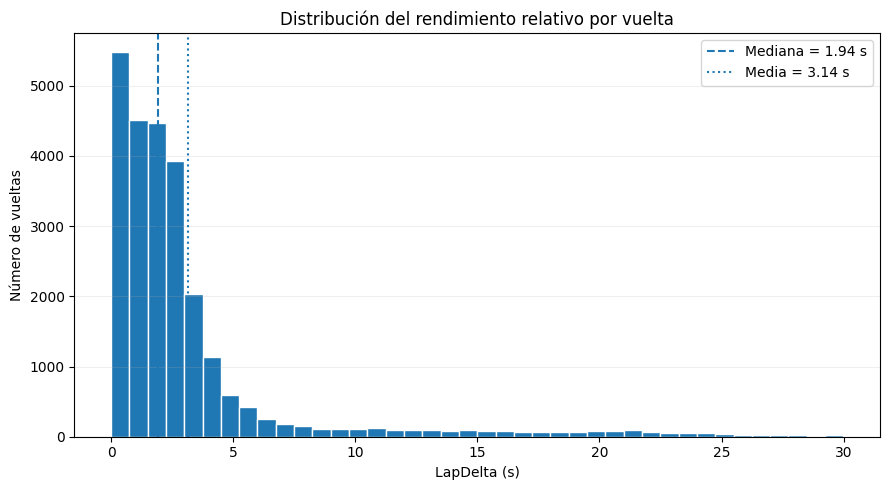

count    25150.000
mean         3.141
std          4.421
min          0.000
25%          0.861
50%          1.940
75%          3.133
90%          6.168
95%         13.442
max         29.990
Name: LapDelta, dtype: float64

In [17]:
#Distribución de LapDelta

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(df["LapDelta"], bins=40, edgecolor="white")
ax.axvline(df["LapDelta"].median(), linestyle="--", linewidth=1.5, label=f"Mediana = {df['LapDelta'].median():.2f} s")
ax.axvline(df["LapDelta"].mean(), linestyle=":", linewidth=1.5, label=f"Media = {df['LapDelta'].mean():.2f} s")

ax.set_title("Distribución del rendimiento relativo por vuelta")
ax.set_xlabel("LapDelta (s)")
ax.set_ylabel("Número de vueltas")
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

display(df["LapDelta"].describe(percentiles=[.25,.5,.75,.90,.95]).round(3))

### Comparación del rendimiento relativo entre pilotos

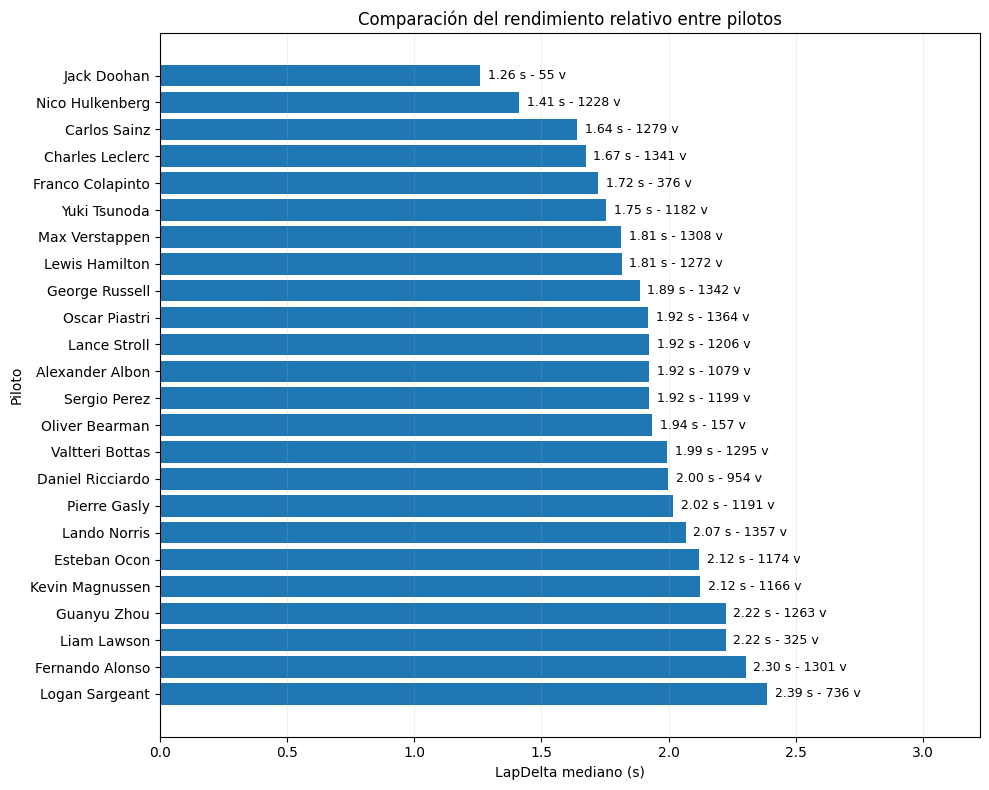

,Piloto,LapDelta_med,N
0,Jack Doohan,1.259,55
1,Nico Hulkenberg,1.413,1228
2,Carlos Sainz,1.639,1279
3,Charles Leclerc,1.673,1341
4,Franco Colapinto,1.723,376
5,Yuki Tsunoda,1.753,1182
6,Max Verstappen,1.812,1308
7,Lewis Hamilton,1.815,1272
8,George Russell,1.886,1342
9,Oscar Piastri,1.919,1364


In [18]:
#Comparación del rendimiento relativo entre pilotos

driver_performance = df.groupby("Driver").agg(LapDelta_med=("LapDelta","median"), N=("LapDelta","size")).reset_index()
driver_performance["Piloto"] = driver_performance["Driver"].map(driver_names).fillna(driver_performance["Driver"])
driver_performance = driver_performance.sort_values("LapDelta_med", ascending=True)

fig, ax = plt.subplots(figsize=(10,8))
bars = ax.barh(driver_performance["Piloto"], driver_performance["LapDelta_med"])

for bar, value, n in zip(bars, driver_performance["LapDelta_med"], driver_performance["N"]):
    ax.text(value + 0.03, bar.get_y() + bar.get_height()/2, f"{value:.2f} s - {n} v", va="center", fontsize=9)

ax.invert_yaxis()
ax.set_xlim(0, driver_performance["LapDelta_med"].max()*1.35)
ax.set_title("Comparación del rendimiento relativo entre pilotos")
ax.set_xlabel("LapDelta mediano (s)")
ax.set_ylabel("Piloto")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

display(driver_performance[["Piloto","LapDelta_med","N"]].reset_index(drop=True).round(3))

### Comparación de la evolución del rendimiento relativo entre pilotos

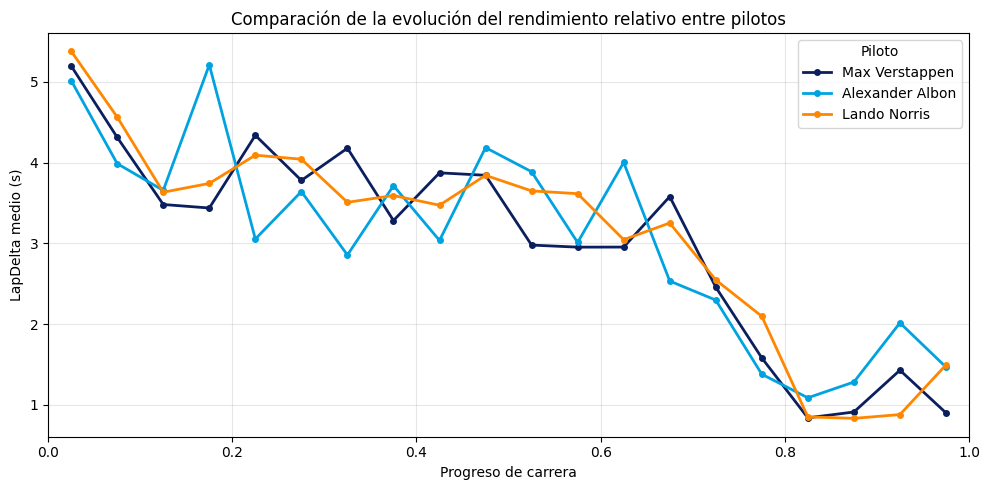

,Piloto,LapDelta_mediano
Q25,Max Verstappen,1.812
Mediana,Alexander Albon,1.923
Q75,Lando Norris,2.067


In [19]:
#Comparación de la evolución del rendimiento relativo entre pilotos

driver_medians = df.groupby("Driver")["LapDelta"].median().sort_values()
targets = driver_medians.quantile([0.25, 0.50, 0.75])
drivers_to_plot = [abs(driver_medians - value).idxmin() for value in targets]

plot_df = df[df["Driver"].isin(drivers_to_plot)].copy()
plot_df["LapProgressBin"] = pd.cut(plot_df["LapProgress"], bins=np.linspace(0, 1, 21), labels=False, include_lowest=True)

summary_df = plot_df.groupby(["Driver","LapProgressBin"])["LapDelta"].mean().reset_index()
summary_df["RaceProgress"] = (summary_df["LapProgressBin"] + 0.5) / 20
colors = {"VER":"#0B1F5E", "ALB":"#00A3E0", "NOR":"#FF8700"}

fig, ax = plt.subplots(figsize=(10,5))

for driver in drivers_to_plot:
    temp = summary_df[summary_df["Driver"] == driver]
    ax.plot(temp["RaceProgress"], temp["LapDelta"], marker="o", markersize=4, linewidth=2, color=colors.get(driver), label=driver_names.get(driver,driver))

ax.set_title("Comparación de la evolución del rendimiento relativo entre pilotos")
ax.set_xlabel("Progreso de carrera")
ax.set_ylabel("LapDelta medio (s)")
ax.set_xlim(0,1)
ax.legend(title="Piloto")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
display(pd.DataFrame({"Piloto":[driver_names.get(d,d) for d in drivers_to_plot], "LapDelta_mediano":[driver_medians[d] for d in drivers_to_plot]}, index=["Q25","Mediana","Q75"]).round(3))

### Evolución media del rendimiento según el progreso de carrera

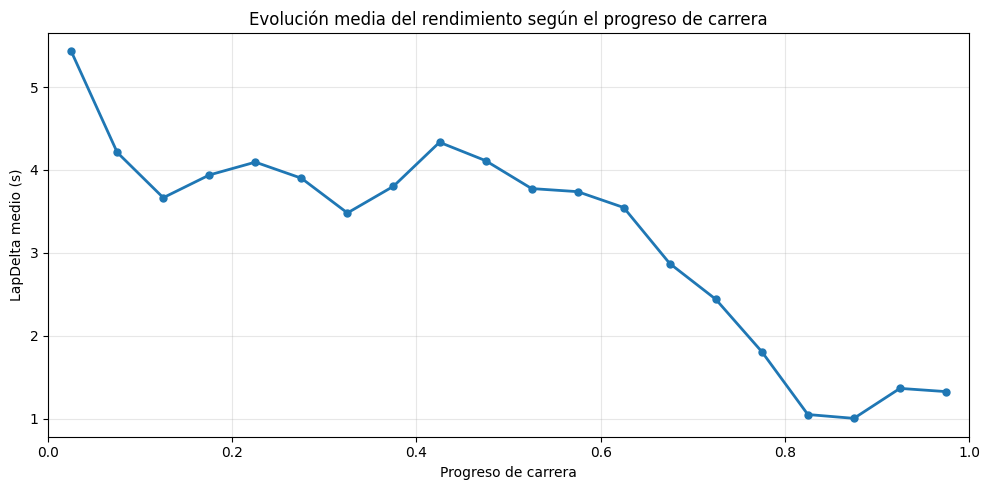

In [20]:
#Evolución media del rendimiento según el progreso de carrera

progress_df = df.copy()
progress_df["LapProgressBin"] = pd.cut(progress_df["LapProgress"], bins=np.linspace(0, 1, 21), labels=False, include_lowest=True)

progress_summary = progress_df.groupby("LapProgressBin")["LapDelta"].mean().reset_index()
progress_summary["RaceProgress"] = (progress_summary["LapProgressBin"] + 0.5) / 20

plt.figure(figsize=(10, 5))
plt.plot(progress_summary["RaceProgress"], progress_summary["LapDelta"], marker="o", markersize=5, linewidth=2)
plt.title("Evolución media del rendimiento según el progreso de carrera")
plt.xlabel("Progreso de carrera")
plt.ylabel("LapDelta medio (s)")
plt.xlim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Evolución del rendimiento en función de la vida del neumático

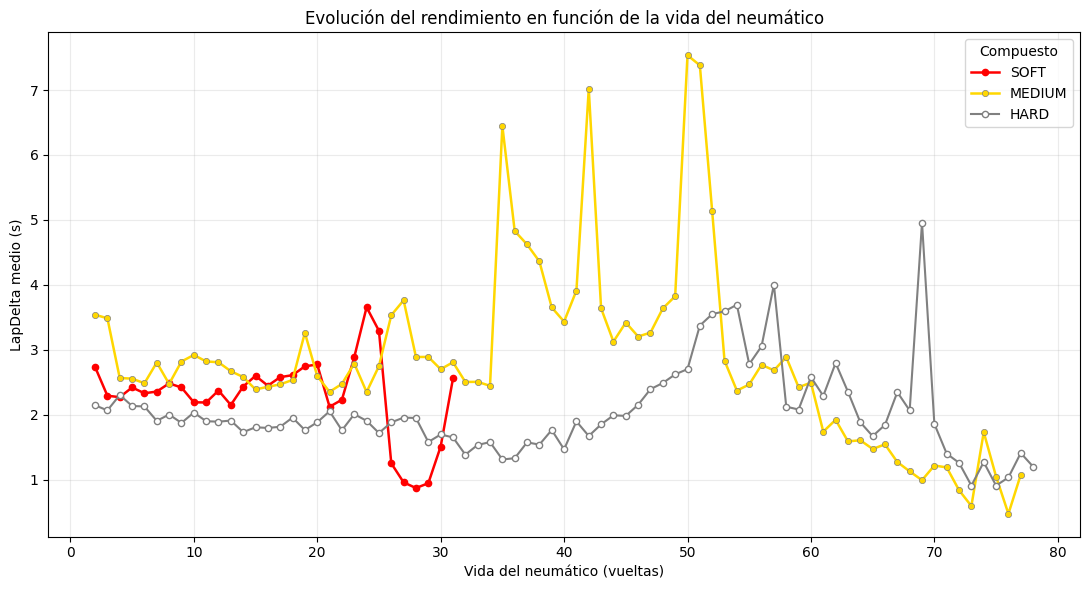

,Compound,TyreLife,LapDelta_mean,N
0,HARD,78.0,1.199500,2
1,HARD,77.0,1.408600,5
2,MEDIUM,77.0,1.075000,1
3,HARD,76.0,1.032429,7
4,MEDIUM,76.0,0.472667,3
...,...,...,...,...
178,MEDIUM,3.0,3.484575,386
179,SOFT,3.0,2.291310,87
180,HARD,2.0,2.144364,371
181,MEDIUM,2.0,3.538938,341


In [21]:
#Evolución del rendimiento en función de la vida del neumático

tyre_df = df[(df["TyreLife"] >= 1) & (~df["StintStart"]) & (df["Compound"].isin(["SOFT", "MEDIUM", "HARD"]))].copy()
summary = tyre_df.groupby(["Compound", "TyreLife"])["LapDelta"].agg(LapDelta_mean="mean", N="size").reset_index()

soft = summary[summary["Compound"] == "SOFT"]
medium = summary[summary["Compound"] == "MEDIUM"]
hard = summary[summary["Compound"] == "HARD"]

plt.figure(figsize=(11,6))
plt.plot(soft["TyreLife"], soft["LapDelta_mean"], color="red", marker="o", markersize=4.5, linewidth=1.8, label="SOFT")
plt.plot(medium["TyreLife"], medium["LapDelta_mean"], color="gold", marker="o", markersize=4.5, markeredgecolor="gray", markeredgewidth=.5, linewidth=1.8, label="MEDIUM")
plt.plot(hard["TyreLife"], hard["LapDelta_mean"], color="gray", marker="o", markerfacecolor="white", markeredgecolor="gray", markersize=4.5, linewidth=1.5, label="HARD")
plt.title("Evolución del rendimiento en función de la vida del neumático")
plt.xlabel("Vida del neumático (vueltas)")
plt.ylabel("LapDelta medio (s)")
plt.legend(title="Compuesto")
plt.grid(alpha=.25)
plt.tight_layout()
plt.show()

display(summary.sort_values(["TyreLife", "Compound"], ascending=[False, True]).reset_index(drop=True))

In [22]:
# Antigüedad máxima del neumático por Gran Premio

secos = df[df["Compound"].isin(["SOFT", "MEDIUM", "HARD"])].copy()

tyrelife_gp = secos.groupby(["GP_file", "Compound"])["TyreLife"].max().unstack().reindex(columns=["SOFT", "MEDIUM", "HARD"])
max_gp = tyrelife_gp.max(axis=1)
vueltas_max = secos[secos["TyreLife"].eq(secos["GP_file"].map(max_gp))].groupby("GP_file").size()

tyrelife_gp = tyrelife_gp.reset_index()
tyrelife_gp["Vueltas_max"] = tyrelife_gp["GP_file"].map(vueltas_max)
tyrelife_gp["GP"] = tyrelife_gp["GP_file"].replace(gp_labels_val)
tyrelife_gp["Orden"] = tyrelife_gp[["SOFT", "MEDIUM", "HARD"]].max(axis=1)
tyrelife_gp = tyrelife_gp.sort_values("Orden", ascending=False)

display(tyrelife_gp[["GP", "SOFT", "MEDIUM", "HARD", "Vueltas_max"]].style.hide(axis="index").format(precision=0, na_rep="--"))

GP,SOFT,MEDIUM,HARD,Vueltas_max
Mónaco,28,77,78,2
Países Bajos,24,33,57,1
Emilia-Romaña,8,38,54,1
Azerbaiyán,--,18,52,1
México,5,39,50,1
Singapur,31,38,49,1
Abu Dabi,25,29,45,2
Miami,29,36,45,1
Arabia Saudí,19,41,44,2
Italia,2,21,43,1


### Rendimiento medio según compuesto y fase de carrera

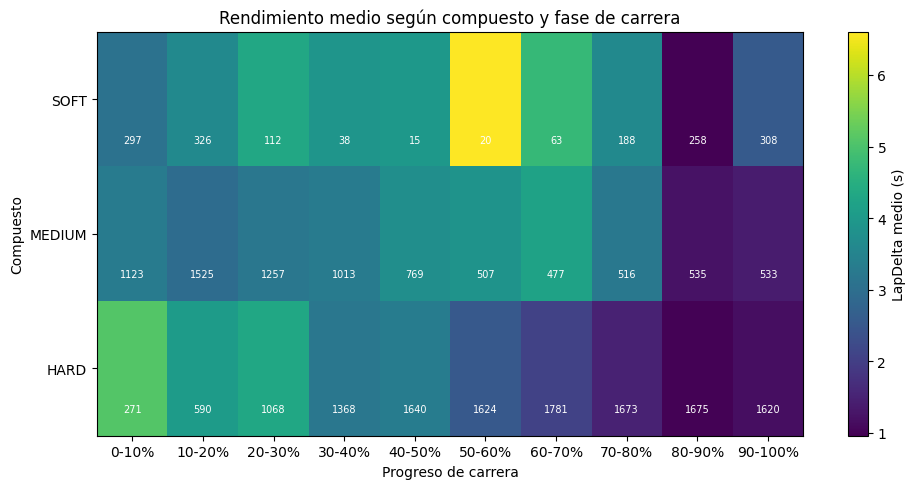

,Compound,ProgressBin,LapDelta_mean,N
0,HARD,0-10%,5.097402,271
1,HARD,10-20%,4.053036,590
2,HARD,20-30%,4.310721,1068
3,HARD,30-40%,3.205788,1368
4,HARD,40-50%,3.336783,1640
5,HARD,50-60%,2.527500,1624
6,HARD,60-70%,2.075243,1781
7,HARD,70-80%,1.497597,1673
8,HARD,80-90%,0.987120,1675
9,HARD,90-100%,1.165563,1620


In [23]:
#Rendimiento medio según compuesto y fase de carrera

heat_df = df[df["Compound"].isin(["SOFT", "MEDIUM", "HARD"])].copy()

labels = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]
heat_df["ProgressBin"] = pd.cut(heat_df["LapProgress"], bins=np.linspace(0, 1, 11), labels=labels, include_lowest=True)

summary_heat = heat_df.groupby(["Compound", "ProgressBin"], observed=True)["LapDelta"].agg(LapDelta_mean="mean", N="size").reset_index()
heat = summary_heat.pivot(index="Compound", columns="ProgressBin", values="LapDelta_mean").reindex(index=["SOFT", "MEDIUM", "HARD"], columns=labels)
heat_n = summary_heat.pivot(index="Compound", columns="ProgressBin", values="N").reindex(index=["SOFT", "MEDIUM", "HARD"], columns=labels)

fig, ax = plt.subplots(figsize=(10,5))
im = ax.imshow(heat, aspect="auto")
fig.colorbar(im, ax=ax, label="LapDelta medio (s)")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)

for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        ax.text(j, i + 0.30, f"{int(heat_n.iloc[i,j])}", ha="center", va="center", color="white", fontsize=7)

ax.set_title("Rendimiento medio según compuesto y fase de carrera")
ax.set_xlabel("Progreso de carrera")
ax.set_ylabel("Compuesto")
plt.tight_layout()
plt.show()

display(summary_heat.sort_values(["Compound", "ProgressBin"]).reset_index(drop=True))

## Preprocesamiento de los datos

Antes del entrenamiento de los modelos, las variables predictoras se clasificaron en numéricas y categóricas para aplicar a cada grupo el preprocesamiento correspondiente.

Las variables numéricas se estandarizan mediante StandardScaler y las categóricas se transforman mediante OneHotEncoder. En los modelos por piloto se utiliza Compound como variable categórica y, en el modelo global, se incorpora la variable Driver.

In [24]:
#Variables utilizadas en los modelos

base_features = ["TyreLife", "LapProgress", "Stint", "TyreDeg", "Compound"]
global_features = base_features + ["Driver"]
numeric_features = ["TyreLife", "LapProgress", "Stint", "TyreDeg"]

#Preprocesamiento común

def create_preprocessor(include_driver=False):
    categorical_features = ["Compound"]

    if include_driver:
        categorical_features.append("Driver")

    return ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ])

## Modelos de regresión utilizados

En los distintos procedimientos, se comparan cuatro modelos de regresión:

Ridge: regresión lineal regularizada, utilizada como referencia lineal para comprobar si un modelo lineal es suficiente para predecir LapDelta y comparar sus resultados con los modelos no lineales.

RandomForestRegressor: representa relaciones no lineales mediante un conjunto de árboles de decisión independientes entrenados en paralelo (bagging).

GradientBoostingRegressor: construye árboles de forma secuencial que optimiza la función de pérdida corrigiendo los errores de los árboles previos (boosting).

HistGradientBoostingRegressor: variante basada en histogramas, diseñada para realizar el entrenamiento de forma más eficiente y para el manejo de grandes volúmenes de datos.

In [25]:
def create_models():
    return {
        "Ridge": Ridge(alpha=1.0),
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
        "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=6, random_state=42)
    }

## Primera prueba: evaluación sobre un único Gran Premio (Baréin)

Como primera aproximación se evalúan los modelos reservando un único Gran Premio (Baréin) como conjunto de test. El objetivo es comprobar el funcionamiento de los cuatro modelos sobre una carrera que no ha sido utilizada durante el entrenamiento antes de realizar una validación más amplia entre grandes premios. Sus resultados se interpretan como preliminares.

### Comparación de modelos

Para evaluar la capacidad predictiva, se define una función de entrenamiento individual por piloto, para aplicar el mismo proceso a todos los pilotos participantes, manteniendo la misma metodología en todos los casos.

La variable objetivo del modelo es la calculada LapDelta. Para las variables predictoras se utiliza información relacionada con el progreso de carrera y el uso del neumático.

Como evaluación se utiliza un enfoque hold out por gran premio, dejando fuera del entrenamiento el Gran Premio de Baréin, que se utiliza solo como conjunto de test.

In [26]:
#Función de entrenamiento por piloto

def train_driver_model(driver_code, test_gp="Bahrain_Grand_Prix"):
    driver_name = driver_names.get(driver_code, driver_code)
    df_driver = df[df["Driver"] == driver_code].copy()

    X = df_driver[base_features]
    y = df_driver["LapDelta"]

    mask_test = df_driver["GP_file"] == test_gp
    X_train = X[~mask_test]
    y_train = y[~mask_test]
    X_test = X[mask_test]
    y_test = y[mask_test]

    if len(X_train) == 0 or len(X_test) == 0:
        return None

    results = []
    trained_models = {}

    for name, estimator in create_models().items():
        model = Pipeline([("prep", create_preprocessor()), ("model", estimator)])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append([driver_name, name, mean_absolute_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred)), r2_score(y_test, y_pred)])
        
        trained_models[name] = model

    results_df = pd.DataFrame(results, columns=["Driver", "Model", "MAE", "RMSE", "R2"]).sort_values("R2", ascending=False)

    return results_df, trained_models, X_test, y_test

### Ejecución del modelo

Una vez definida la función de entrenamiento, se ejecuta el proceso para todos los pilotos participantes en el Gran Premio de Baréin, con el objetivo de comparar el comportamiento de distintos modelos de regresión sobre un mismo conjunto de prueba.

In [27]:
#Pilotos participantes en el Gran Premio de Baréin

test_gp = "Bahrain_Grand_Prix"
drivers_to_analyze = sorted(df.loc[df["GP_file"] == test_gp, "Driver"].unique())

print(f"Número de pilotos analizados: {len(drivers_to_analyze)}")

all_results = []
driver_outputs = {}

for driver in drivers_to_analyze:
    output = train_driver_model(driver, test_gp=test_gp)

    if output is not None:
        results_df, trained_models, X_test, y_test = output
        all_results.append(results_df)
        driver_outputs[driver] = {"models": trained_models, "X_test": X_test, "y_test": y_test}

Número de pilotos analizados: 20


### Resultados numéricos

Se obtienen los resultados para los modelos Ridge, Random Forest, Gradient Boosting y HistGradientBoosting utilizando como métricas de evaluación el error absoluto medio (MAE), la raíz del error cuadrático medio (RMSE) y el coeficiente de determinación (R2).

A partir de estos resultados, se compara el valor de R2 obtenido por cada modelo y se identifica para cada piloto el modelo que alcanza el mayor R2. También se realiza un resumen estadístico de las métricas del mejor modelo de cada piloto.

In [28]:
#Resultados de todos los pilotos

final_results = pd.concat(all_results, ignore_index=True)
final_results = final_results.sort_values(["Driver", "R2"], ascending=[True, False]).reset_index(drop=True)

In [29]:
#R2 de cada modelo por piloto en Baréin

model_order = ["Ridge","RandomForest","GradientBoosting","HistGradientBoosting"]

r2_barein = final_results.pivot(index="Driver",columns="Model",values="R2")[model_order].reset_index().rename_axis(None,axis=1)

display(r2_barein.style.hide(axis="index").format(precision=3))

Driver,Ridge,RandomForest,GradientBoosting,HistGradientBoosting
Alexander Albon,0.046,0.854,0.804,0.888
Carlos Sainz,0.078,0.448,0.878,0.888
Charles Leclerc,0.091,0.747,0.771,0.836
Daniel Ricciardo,-0.051,0.478,0.543,0.458
Esteban Ocon,0.024,0.911,0.867,0.909
Fernando Alonso,0.065,0.704,0.740,0.672
George Russell,0.078,0.859,0.897,0.857
Guanyu Zhou,0.070,0.787,0.843,0.808
Kevin Magnussen,0.062,0.812,0.860,0.884
Lance Stroll,0.085,0.395,0.643,0.373


In [30]:
#Mejor modelo por piloto

best_models = final_results.loc[final_results.groupby("Driver")["R2"].idxmax()].copy()
best_models = best_models.sort_values("R2", ascending=False).reset_index(drop=True)

display(best_models)
display(best_models["Model"].value_counts().rename("N_pilotos"))
display(best_models[["R2", "MAE", "RMSE"]].describe().round(3))

,Driver,Model,MAE,RMSE,R2
0,Oscar Piastri,HistGradientBoosting,0.858196,1.267447,0.915020
1,Esteban Ocon,RandomForest,0.784941,1.234315,0.910559
2,George Russell,GradientBoosting,0.964435,1.314379,0.896693
3,Lando Norris,GradientBoosting,0.909337,1.308700,0.894320
4,Yuki Tsunoda,GradientBoosting,0.802358,1.350646,0.889562
5,Carlos Sainz,HistGradientBoosting,0.876275,1.316443,0.888179
6,Alexander Albon,HistGradientBoosting,0.894804,1.368944,0.887700
7,Kevin Magnussen,HistGradientBoosting,0.936139,1.379615,0.883571
8,Lewis Hamilton,RandomForest,0.946835,1.378931,0.879777
9,Pierre Gasly,HistGradientBoosting,1.396008,2.080726,0.853344


Model
GradientBoosting        9
HistGradientBoosting    8
RandomForest            3
Name: N_pilotos, dtype: int64

,R2,MAE,RMSE
count,20.000,20.000,20.000
mean,0.802,1.128,1.746
std,0.151,0.350,0.577
min,0.301,0.785,1.234
25%,0.801,0.892,1.316
50%,0.852,1.018,1.488
75%,0.889,1.244,2.035
max,0.915,2.241,3.384


### Visualización de resultados

Para complementar el análisis numérico, se representan gráficamente los principales resultados obtenidos en la prueba de Baréin. Con estas visualizaciones se puede comparar el comportamiento de los modelos, observar las diferencias entre pilotos y analizar con mayor detalle la capacidad predictiva obtenida.

#### Comparación del rendimiento predictivo entre modelos

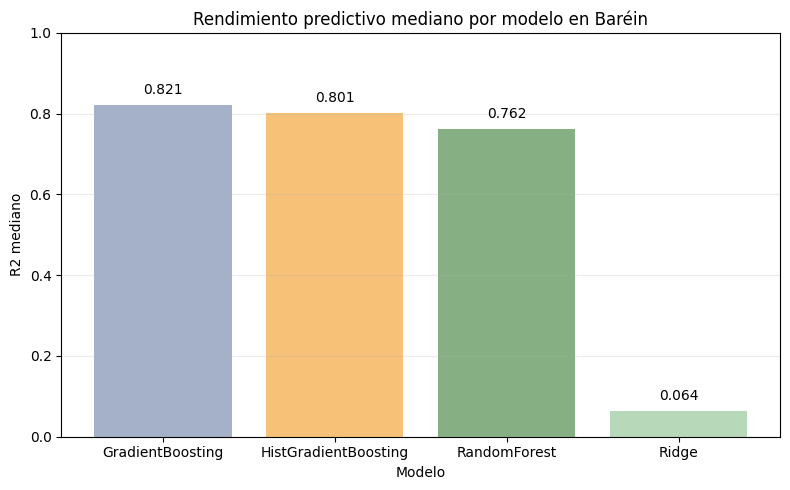

In [31]:
#Comparación del rendimiento predictivo entre modelos

color_map = {"GradientBoosting":"#A5B1C9","HistGradientBoosting":"#F7C278","RandomForest":"#86B083","Ridge":"#B8D8BA"}
model_summary = final_results.groupby("Model")["R2"].median().sort_values(ascending=False)
best_model_bahrain = model_summary.index[0]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_summary.index, model_summary.values, color=[color_map[m] for m in model_summary.index])

for bar, value in zip(bars, model_summary.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.02, f"{value:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Rendimiento predictivo mediano por modelo en Baréin")
ax.set_xlabel("Modelo")
ax.set_ylabel("R2 mediano")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

#### Mejor capacidad predictiva obtenida por piloto

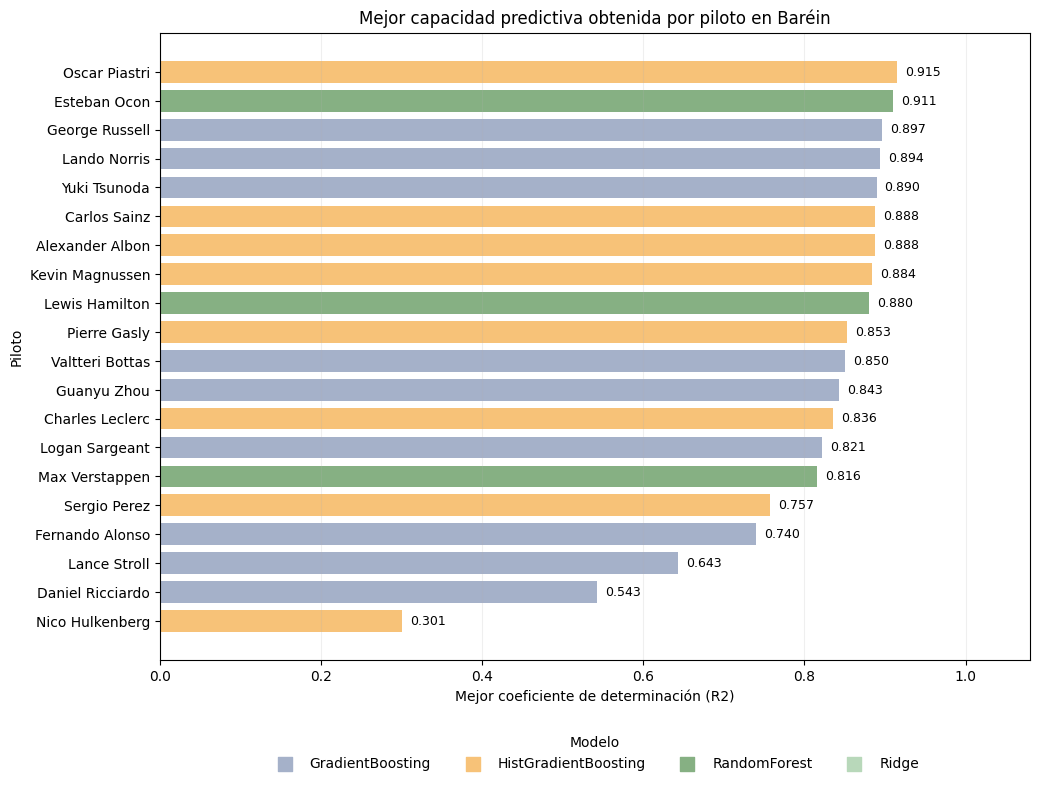

In [32]:
#Mejor capacidad predictiva obtenida por piloto

plot_df = best_models.sort_values("R2", ascending=True).reset_index(drop=True)
y = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(10.5, 8.5))
bars = ax.barh(y, plot_df["R2"], color=plot_df["Model"].map(color_map), height=0.75)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["Driver"])

for bar, r2 in zip(bars, plot_df["R2"]):
    ax.text(r2 + 0.01, bar.get_y() + bar.get_height()/2, f"{r2:.3f}", va="center", ha="left", fontsize=9)

for model, color in color_map.items():
    ax.scatter([], [], marker="s", s=90, color=color, label=model)

ax.set_title("Mejor capacidad predictiva obtenida por piloto en Baréin")
ax.set_xlabel("Mejor coeficiente de determinación (R2)")
ax.set_ylabel("Piloto")
ax.set_xlim(0, 1.08)
ax.grid(axis="x", alpha=0.2)
ax.legend(title="Modelo", ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.10), frameon=False)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

#### Comparación entre LapDelta real y predicho

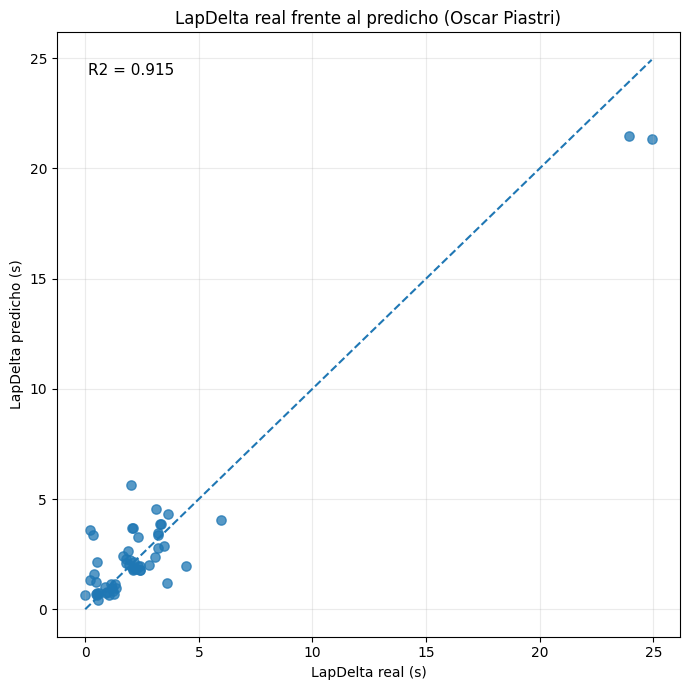

In [33]:
#Comparación entre LapDelta real y predicho

best_case = best_models.loc[best_models["R2"].idxmax()]
driver_name = best_case["Driver"]
best_model_name = best_case["Model"]
r2_value = best_case["R2"]

driver_code = next(code for code, name in driver_names.items() if name == driver_name)

best_model = driver_outputs[driver_code]["models"][best_model_name]
X_test = driver_outputs[driver_code]["X_test"]
y_test = driver_outputs[driver_code]["y_test"]
y_pred = best_model.predict(X_test)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.75, s=45)
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1.5)
ax.set_title(f"LapDelta real frente al predicho ({driver_name})")
ax.set_xlabel("LapDelta real (s)")
ax.set_ylabel("LapDelta predicho (s)")
ax.text(0.05, 0.93, f"R2 = {r2_value:.3f}", transform=ax.transAxes, fontsize=11)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Evolución del LapDelta real frente al predicho

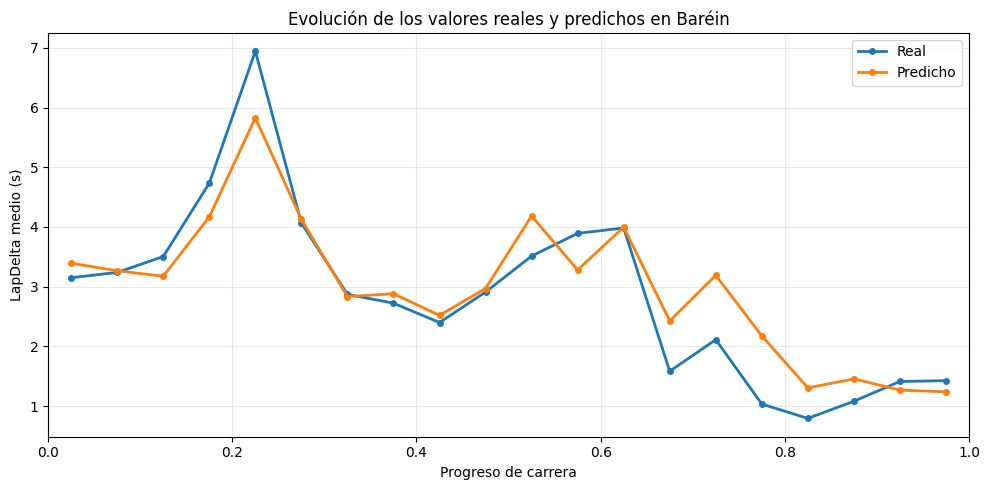

,LapProgressBin,LapDelta_real,LapDelta_predicho,RaceProgress
0,0,3.149,3.390,0.025
1,1,3.238,3.267,0.075
2,2,3.504,3.173,0.125
3,3,4.734,4.168,0.175
4,4,6.945,5.828,0.225
5,5,4.065,4.127,0.275
6,6,2.871,2.833,0.325
7,7,2.722,2.881,0.375
8,8,2.399,2.518,0.425
9,9,2.909,2.968,0.475


In [34]:
#Evolución del LapDelta real frente al predicho

pred_barein = []

for driver_code, output in driver_outputs.items():
    X_test = output["X_test"]
    y_test = output["y_test"]
    y_pred = output["models"][best_model_bahrain].predict(X_test)
    pred_barein.append(pd.DataFrame({"LapProgress": X_test["LapProgress"].values, "LapDelta_real": y_test.values, "LapDelta_predicho": y_pred}))

pred_barein_df = pd.concat(pred_barein, ignore_index=True)
pred_barein_df["LapProgressBin"] = pd.cut(pred_barein_df["LapProgress"], bins=np.linspace(0, 1, 21), labels=False, include_lowest=True)

curva_barein = pred_barein_df.groupby("LapProgressBin")[["LapDelta_real", "LapDelta_predicho"]].mean().reset_index()
curva_barein["RaceProgress"] = (curva_barein["LapProgressBin"] + 0.5) / 20

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(curva_barein["RaceProgress"], curva_barein["LapDelta_real"], marker="o", markersize=4, linewidth=2, label="Real")
ax.plot(curva_barein["RaceProgress"], curva_barein["LapDelta_predicho"], marker="o", markersize=4, linewidth=2, label="Predicho")
ax.set_title("Evolución de los valores reales y predichos en Baréin")
ax.set_xlabel("Progreso de carrera")
ax.set_ylabel("LapDelta medio (s)")
ax.set_xlim(0,1)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(curva_barein.round(3))

#### Importancia relativa de las variables en la predicción del rendimiento

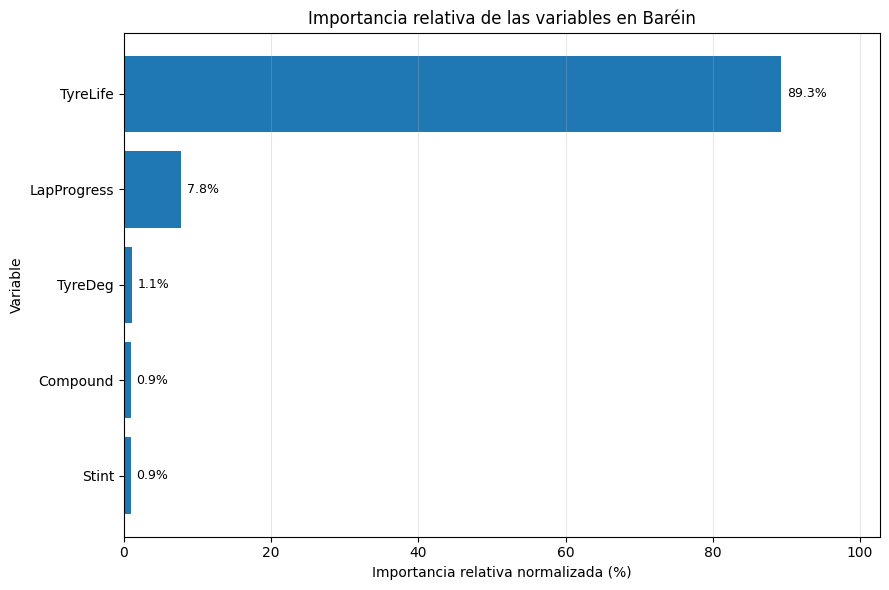

,Q25,Mediana,Q75
Variable,,,
TyreLife,1.173,1.418,1.589
LapProgress,0.082,0.123,0.263
TyreDeg,-0.011,0.017,0.166
Compound,0.004,0.015,0.035
Stint,0.004,0.015,0.099


Variable,Compound,LapProgress,Stint,TyreDeg,TyreLife
Driver,,,,,
Lance Stroll,-0.016,2.899,1.324,0.554,2.104
Max Verstappen,-0.017,0.266,0.411,-0.063,1.798
Charles Leclerc,0.007,0.015,0.063,-0.014,1.708
Kevin Magnussen,-0.013,0.087,0.137,-0.008,1.707
Lando Norris,0.035,0.109,0.001,0.312,1.642
Carlos Sainz,0.029,0.066,0.248,0.005,1.571
Yuki Tsunoda,0.024,0.095,0.059,0.019,1.506
Sergio Perez,0.087,0.262,0.008,-0.021,1.497
Alexander Albon,0.014,0.068,0.015,0.015,1.492


In [35]:
#Importancia de las variables en Baréin

importance_bahrain = []

for driver_code, output in driver_outputs.items():
    driver_name = driver_names.get(driver_code, driver_code)
    best_model_name = best_models.loc[best_models["Driver"] == driver_name, "Model"].iloc[0]
    model = output["models"][best_model_name]
    X_test_driver = output["X_test"]
    y_test_driver = output["y_test"]

    perm = permutation_importance(model, X_test_driver, y_test_driver, n_repeats=20, random_state=42, scoring="r2", n_jobs=-1)

    for variable, importance in zip(X_test_driver.columns, perm.importances_mean):
        importance_bahrain.append({"Driver": driver_name, "Variable": variable, "Importancia": importance})

importance_bahrain = pd.DataFrame(importance_bahrain)

imp_bahrain = importance_bahrain.groupby("Variable")["Importancia"].median().clip(lower=0)
imp_bahrain = (100 * imp_bahrain / imp_bahrain.sum()).sort_values()

fig, ax = plt.subplots(figsize=(9,6))
bars = ax.barh(imp_bahrain.index, imp_bahrain.values)

for bar, value in zip(bars, imp_bahrain.values):
    ax.text(value + 0.8, bar.get_y() + bar.get_height()/2, f"{value:.1f}%", va="center", fontsize=9)

ax.set_title("Importancia relativa de las variables en Baréin")
ax.set_xlabel("Importancia relativa normalizada (%)")
ax.set_ylabel("Variable")
ax.set_xlim(0, imp_bahrain.max()*1.15)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(importance_bahrain.groupby("Variable")["Importancia"].agg(Q25=lambda x: x.quantile(.25), Mediana="median", Q75=lambda x: x.quantile(.75)).sort_values("Mediana", ascending=False).round(3))
display(importance_bahrain.pivot(index="Driver", columns="Variable", values="Importancia").sort_values("TyreLife", ascending=False).round(3))

## Validación y análisis del modelo

Se evalúa la capacidad de generalización de los modelos mediante la validación entre grandes premios, y se analiza cómo varía su capacidad predictiva al utilizar diferentes carreras como conjunto de testing. 

### Validación entre grandes premios

Para ampliar la evaluación realizada inicialmente sobre Baréin, se lleva a cabo una validación por piloto entre grandes premios. En cada evaluación se reserva un gran premio completo como conjunto de testing y se utilizan las vueltas del resto de carreras disponibles del piloto para entrenar el modelo.

Para ello, se evaluaron los mismos modelos que en la prueba anterior, un modelo lineal (Ridge), y los modelos no lineales Random Forest, Gradient Boosting y HistGradientBoosting, utilizando las métricas MAE, RMSE y R2, obteniendo para cada circuito una estimación del error de predicción.

Para evitar evaluaciones con conjuntos demasiado pequeños, se utilizan los grandes premios en los que el piloto dispone de al menos 20 vueltas y los casos en los que permanecen al menos 100 vueltas disponibles para el entrenamiento. Los resultados se resumen mediante la mediana, menos sensible a valores extremos que la media. 

#### Ejecución del modelo

La validación sigue un esquema leave one group out, considerando cada gran premio como conjunto independiente. En cada iteración, un circuito completo se deja como conjunto de test y el resto se utiliza para el entrenamiento. Este procedimiento se aplica a los grandes premios que cumplen los mínimos establecidos para cada piloto.

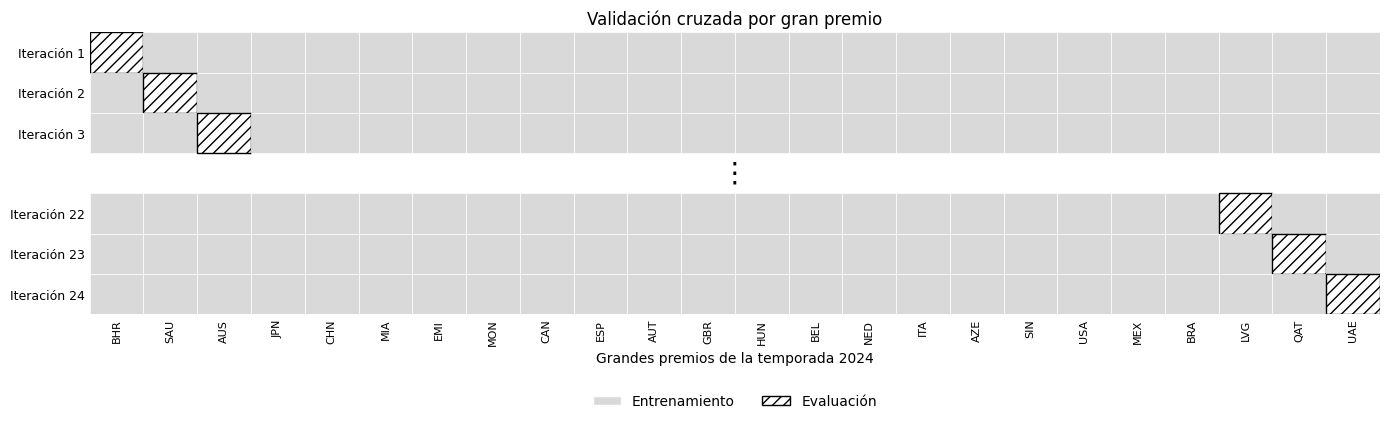

In [36]:
#Esquema de la validación entre Grandes Premios

gp_order = df_GP.sort_values("EventDate")["GP_file"].tolist()

gp_abbr = {
    "Bahrain_Grand_Prix":"BHR","Saudi_Arabian_Grand_Prix":"SAU","Australian_Grand_Prix":"AUS",
    "Japanese_Grand_Prix":"JPN","Chinese_Grand_Prix":"CHN","Miami_Grand_Prix":"MIA",
    "Emilia_Romagna_Grand_Prix":"EMI","Monaco_Grand_Prix":"MON","Canadian_Grand_Prix":"CAN",
    "Spanish_Grand_Prix":"ESP","Austrian_Grand_Prix":"AUT","British_Grand_Prix":"GBR",
    "Hungarian_Grand_Prix":"HUN","Belgian_Grand_Prix":"BEL","Dutch_Grand_Prix":"NED",
    "Italian_Grand_Prix":"ITA","Azerbaijan_Grand_Prix":"AZE","Singapore_Grand_Prix":"SIN",
    "United_States_Grand_Prix":"USA","Mexico_City_Grand_Prix":"MEX","São_Paulo_Grand_Prix":"BRA",
    "Las_Vegas_Grand_Prix":"LVG","Qatar_Grand_Prix":"QAT","Abu_Dhabi_Grand_Prix":"UAE"
}

iterations = [(0,"Iteración 1"),(1,"Iteración 2"),(2,"Iteración 3"),(None,""),(21,"Iteración 22"),(22,"Iteración 23"),(23,"Iteración 24")]

fig, ax = plt.subplots(figsize=(14,4.5))

for row, (test_idx, label) in enumerate(iterations):
    if test_idx is None:
        ax.text(len(gp_order)/2, row+0.5, "⋮", ha="center", va="center", fontsize=20)
        continue

    for col in range(len(gp_order)):
        if col == test_idx:
            rect = Rectangle((col,row),1,1,facecolor="white",edgecolor="black",hatch="///",linewidth=1)
        else:
            rect = Rectangle((col,row),1,1,facecolor="0.85",edgecolor="white",linewidth=0.5)

        ax.add_patch(rect)

ax.set_xlim(0,len(gp_order))
ax.set_ylim(0,len(iterations))
ax.invert_yaxis()
ax.set_xticks(np.arange(len(gp_order))+0.5)
ax.set_xticklabels([gp_abbr[gp] for gp in gp_order],rotation=90,fontsize=8)
ax.set_yticks(np.arange(len(iterations))+0.5)
ax.set_yticklabels([label for _,label in iterations],fontsize=9)
ax.set_xlabel("Grandes premios de la temporada 2024")
ax.set_title("Validación cruzada por gran premio")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both",length=0)
ax.legend(handles=[Patch(facecolor="0.85",edgecolor="white",label="Entrenamiento"), Patch(facecolor="white",edgecolor="black",hatch="///",label="Evaluación")], loc="upper center", bbox_to_anchor=(0.5,-0.24), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

In [37]:
# Validación entre Grandes Premios

df_validation = df.copy()
drivers_to_analyze = sorted(df_validation["Driver"].dropna().unique())
validation_results = []

for driver_code in drivers_to_analyze:
    df_driver = df_validation[df_validation["Driver"] == driver_code]
    gps = df_driver["GP_file"].value_counts()
    gps = gps[gps >= 20].index

    for test_gp in gps:
        train_df = df_driver[df_driver["GP_file"] != test_gp]
        test_df = df_driver[df_driver["GP_file"] == test_gp]

        if len(train_df) < 100:
            continue

        X_train_val = train_df[base_features]
        y_train_val = train_df["LapDelta"]
        X_test_val = test_df[base_features]
        y_test_val = test_df["LapDelta"]

        for model_name, estimator in create_models().items():
            model_val = Pipeline([("prep", create_preprocessor()), ("model", estimator)])

            model_val.fit(X_train_val, y_train_val)
            y_pred_val = model_val.predict(X_test_val)

            validation_results.append({
                "Driver": driver_names.get(driver_code, driver_code),
                "Driver_code": driver_code,
                "Test_GP": test_gp,
                "Model": model_name,
                "MAE": mean_absolute_error(y_test_val, y_pred_val),
                "RMSE": np.sqrt(mean_squared_error(y_test_val, y_pred_val)),
                "R2": r2_score(y_test_val, y_pred_val)
            })

validation_results_df = pd.DataFrame(validation_results)

#### Resultados numéricos
Los resultados de la validación entre grandes premios se resumen para cada combinación de piloto y modelo. Para R2 se calculan además los percentiles 25 y 75 para poder observar cómo varía el rendimiento entre carreras.

In [38]:
#Resultados numéricos

print(f"Pilotos disponibles: {len(drivers_to_analyze)}")
print(f"Pilotos validados: {validation_results_df['Driver'].nunique()}")
print(f"Validaciones piloto-GP: {validation_results_df[['Driver', 'Test_GP']].drop_duplicates().shape[0]}")
print(f"Número total de evaluaciones: {len(validation_results_df)}")

validation_summary = validation_results_df.groupby(["Driver", "Model"]).agg(
    MAE_med=("MAE", "median"),
    RMSE_med=("RMSE", "median"),
    R2_med=("R2", "median"),
    R2_mean=("R2", "mean"),
    R2_std=("R2", "std"),
    R2_q25=("R2", lambda x: x.quantile(.25)),
    R2_q75=("R2", lambda x: x.quantile(.75)),
    N_GP=("R2", "count")
).reset_index()

Pilotos disponibles: 24
Pilotos validados: 23
Validaciones piloto-GP: 449
Número total de evaluaciones: 1796


In [39]:
#Mejor modelo por piloto

mejores_validacion = validation_summary.loc[validation_summary.groupby("Driver")["R2_med"].idxmax(), ["Driver", "Model", "R2_med", "R2_q25", "R2_q75", "MAE_med", "RMSE_med", "N_GP"]]
mejores_validacion = mejores_validacion.sort_values("R2_med", ascending=False).reset_index(drop=True)

In [40]:
#Resumen por piloto

resumen_validacion_fig = mejores_validacion.rename(columns={"R2_med":"R2", "R2_q25":"P25", "R2_q75":"P75", "MAE_med":"MAE", "RMSE_med":"RMSE"})
display(resumen_validacion_fig.round(3))

#Resumen estadístico general

resumen_estadistico_validacion = resumen_validacion_fig[["R2", "MAE", "RMSE"]].describe()
resumen_estadistico_validacion = resumen_estadistico_validacion.rename(index={"count":"N", "mean":"Media", "std":"Desviación estándar", "min":"Mínimo", "25%":"Percentil 25", "50%":"Mediana", "75%":"Percentil 75", "max":"Máximo"})
display(resumen_estadistico_validacion.round(3))

,Driver,Model,R2,P25,P75,MAE,RMSE,N_GP
0,Franco Colapinto,RandomForest,0.740,0.514,0.848,1.216,2.025,8
1,Pierre Gasly,HistGradientBoosting,0.671,-0.078,0.776,1.572,2.373,21
2,Sergio Perez,HistGradientBoosting,0.606,-0.026,0.755,1.521,2.149,22
3,Nico Hulkenberg,GradientBoosting,0.587,0.157,0.737,1.317,2.210,23
4,Max Verstappen,HistGradientBoosting,0.553,0.005,0.778,1.381,1.807,23
5,Carlos Sainz,GradientBoosting,0.541,0.151,0.818,1.166,2.373,23
6,Kevin Magnussen,GradientBoosting,0.493,0.237,0.805,1.302,1.812,21
7,George Russell,HistGradientBoosting,0.475,0.043,0.615,1.456,2.586,24
8,Alexander Albon,HistGradientBoosting,0.474,-0.127,0.739,1.610,2.302,20
9,Charles Leclerc,GradientBoosting,0.467,0.044,0.757,1.226,2.508,24


,R2,MAE,RMSE
N,23.000,23.000,23.000
Media,0.370,1.569,2.598
Desviación estándar,0.317,0.286,0.491
Mínimo,-0.911,1.166,1.807
Percentil 25,0.308,1.356,2.256
Mediana,0.419,1.558,2.586
Percentil 75,0.517,1.644,3.005
Máximo,0.740,2.245,3.739


In [41]:
#R2 mediano de cada modelo por piloto

r2_validacion = validation_summary.pivot(index="Driver", columns="Model", values="R2_med")[model_order].reset_index().rename_axis(None, axis=1)
display(r2_validacion.style.hide(axis="index").format(precision=3))

Driver,Ridge,RandomForest,GradientBoosting,HistGradientBoosting
Alexander Albon,0.024,0.169,0.428,0.474
Carlos Sainz,0.037,0.448,0.541,0.514
Charles Leclerc,0.021,0.379,0.467,0.450
Daniel Ricciardo,-0.010,0.106,0.157,-0.007
Esteban Ocon,-0.069,0.298,0.452,0.459
Fernando Alonso,0.065,0.213,0.213,0.250
Franco Colapinto,0.054,0.740,0.730,0.254
George Russell,0.040,0.354,0.431,0.475
Guanyu Zhou,0.028,0.309,0.298,0.272
Kevin Magnussen,0.062,0.417,0.493,0.397


#### Rendimiento mediano entre grandes premios por modelo

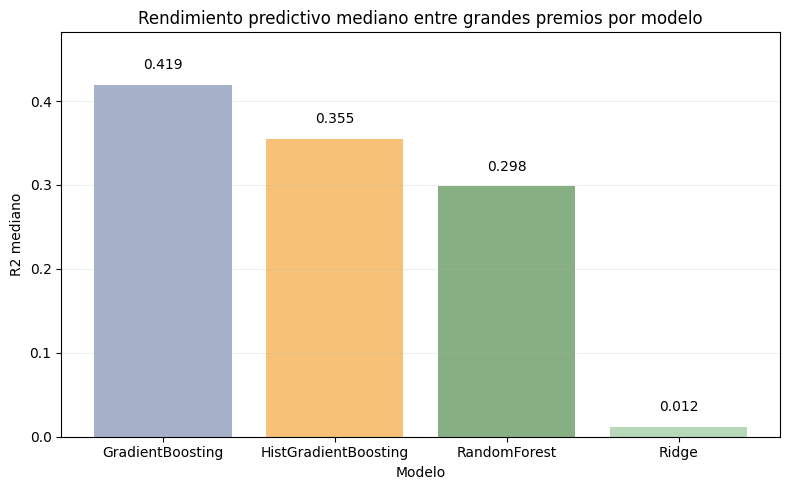

In [42]:
#Rendimiento mediano entre Grandes Premios por modelo

model_summary_val = validation_summary.groupby("Model")["R2_med"].median().sort_values(ascending=False)
best_model_validation = model_summary_val.index[0]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(model_summary_val.index, model_summary_val.values, color=[color_map[m] for m in model_summary_val.index])

for bar, value in zip(bars, model_summary_val.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.015, f"{value:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Rendimiento predictivo mediano entre grandes premios por modelo")
ax.set_xlabel("Modelo")
ax.set_ylabel("R2 mediano")
ax.set_ylim(0, model_summary_val.max()*1.15)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

#### Mejor capacidad predictiva obtenida por piloto en la validación entre grandes premios

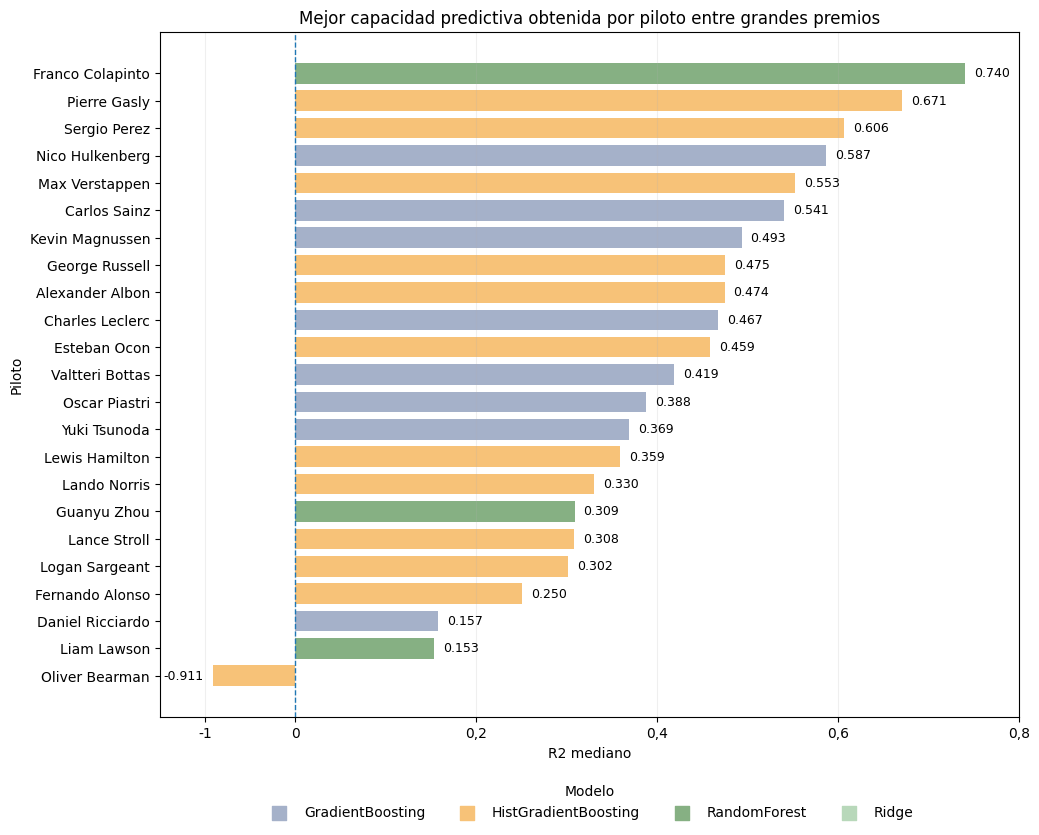

In [43]:
#Mejor capacidad predictiva obtenida por piloto entre grandes premios

plot_df = mejores_validacion.sort_values("R2_med").reset_index(drop=True)
plot_df["R2_plot"] = np.where(plot_df["R2_med"] < 0, plot_df["R2_med"] / 10, plot_df["R2_med"])

fig, ax = plt.subplots(figsize=(10.5, 9))
bars = ax.barh(np.arange(len(plot_df)), plot_df["R2_plot"], color=plot_df["Model"].map(color_map), height=0.75)

ax.set_yticks(np.arange(len(plot_df)))
ax.set_yticklabels(plot_df["Driver"])

for bar, r2, x in zip(bars, plot_df["R2_med"], plot_df["R2_plot"]):
    ax.text(x + (0.01 if r2 >= 0 else -0.01), bar.get_y() + bar.get_height()/2, f"{r2:.3f}", va="center", ha="left" if r2 >= 0 else "right", fontsize=9)

for model, color in color_map.items():
    ax.scatter([], [], marker="s", s=90, color=color, label=model)

ticks = [-1, 0, 0.2, 0.4, 0.6, 0.8]
ax.set_xticks(np.where(np.array(ticks) < 0, np.array(ticks) / 10, np.array(ticks)))
ax.set_xticklabels(["-1", "0", "0,2", "0,4", "0,6", "0,8"])
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Mejor capacidad predictiva obtenida por piloto entre grandes premios")
ax.set_xlabel("R2 mediano")
ax.set_ylabel("Piloto")
ax.set_xlim(-0.15, 0.80)
ax.grid(axis="x", alpha=0.2)
ax.legend(title="Modelo", loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

#### Rendimiento en la validación por gran premio según las condiciones de carrera

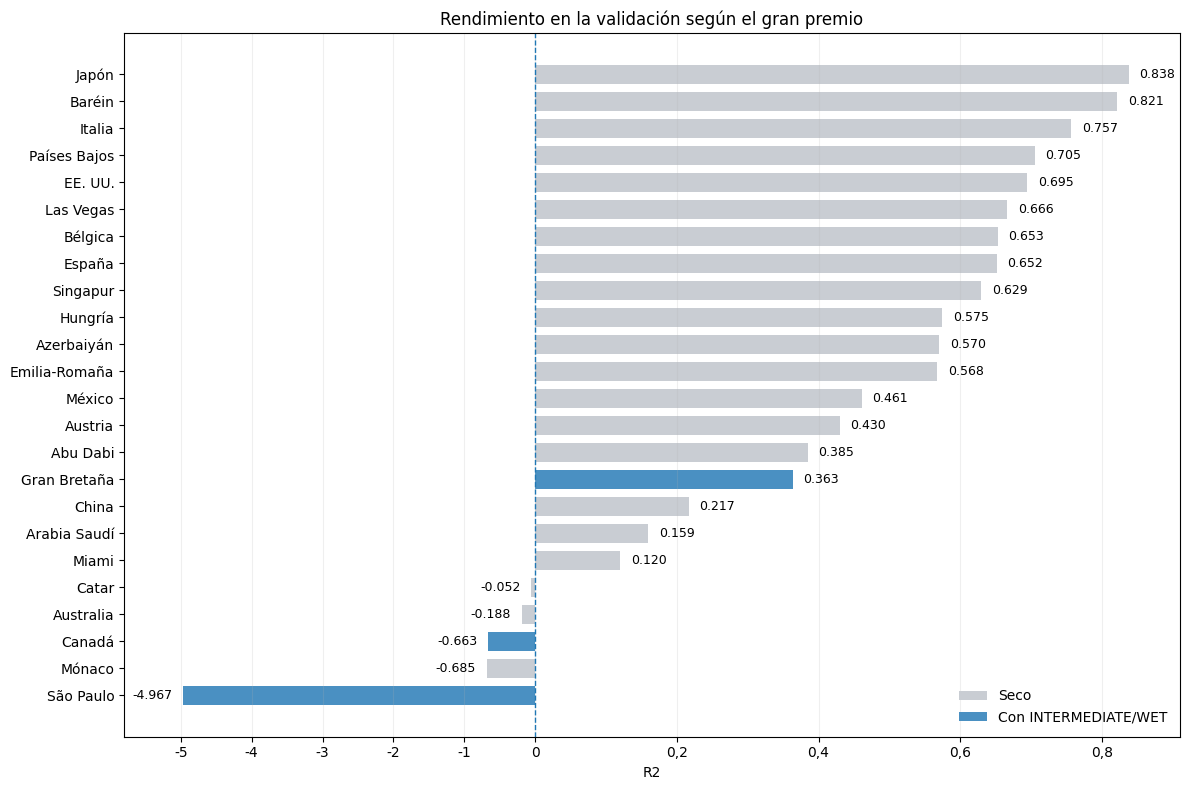

In [44]:
#Rendimiento en la validación por gran premio según las condiciones de carrera

wet_info_val = df.groupby("GP_file")["Compound"].apply(lambda x: x.isin(["INTERMEDIATE", "WET"]).any()).reset_index(name="Condiciones_humedas")
r2_gp_validacion = validation_results_df[validation_results_df["Model"] == best_model_validation].groupby("Test_GP")["R2"].median().reset_index().merge(wet_info_val, left_on="Test_GP", right_on="GP_file")

plot_val_gp = r2_gp_validacion.copy()
plot_val_gp["GP"] = plot_val_gp["Test_GP"].replace(gp_labels_val)
plot_val_gp = plot_val_gp.sort_values("R2").reset_index(drop=True)
plot_val_gp["R2_plot"] = np.where(plot_val_gp["R2"] < 0, plot_val_gp["R2"] / 10, plot_val_gp["R2"])
colors = np.where(plot_val_gp["Condiciones_humedas"], "#4A90C2", "#C9CDD3")

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(plot_val_gp["GP"], plot_val_gp["R2_plot"], color=colors, height=0.7)

for bar, r2, x in zip(bars, plot_val_gp["R2"], plot_val_gp["R2_plot"]):
    ax.text(x + (0.015 if r2 >= 0 else -0.015), bar.get_y() + bar.get_height()/2, f"{r2:.3f}", va="center", ha="left" if r2 >= 0 else "right", fontsize=9)

ticks = [-5, -4, -3, -2, -1, 0, 0.2, 0.4, 0.6, 0.8, 1]
ax.set_xticks(np.where(np.array(ticks) < 0, np.array(ticks) / 10, np.array(ticks)))
ax.set_xticklabels(["-5", "-4", "-3", "-2", "-1", "0", "0,2", "0,4", "0,6", "0,8", "1"])
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Rendimiento en la validación según el gran premio")
ax.set_xlabel("R2")
ax.set_ylabel("")
ax.set_xlim(-0.58, 0.91)
ax.grid(axis="x", alpha=0.2)
ax.legend(handles=[Patch(facecolor="#C9CDD3", label="Seco"), Patch(facecolor="#4A90C2", label="Con INTERMEDIATE/WET")], frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

#### Evolución de los valores reales vs predichos en la validación entre grandes premios

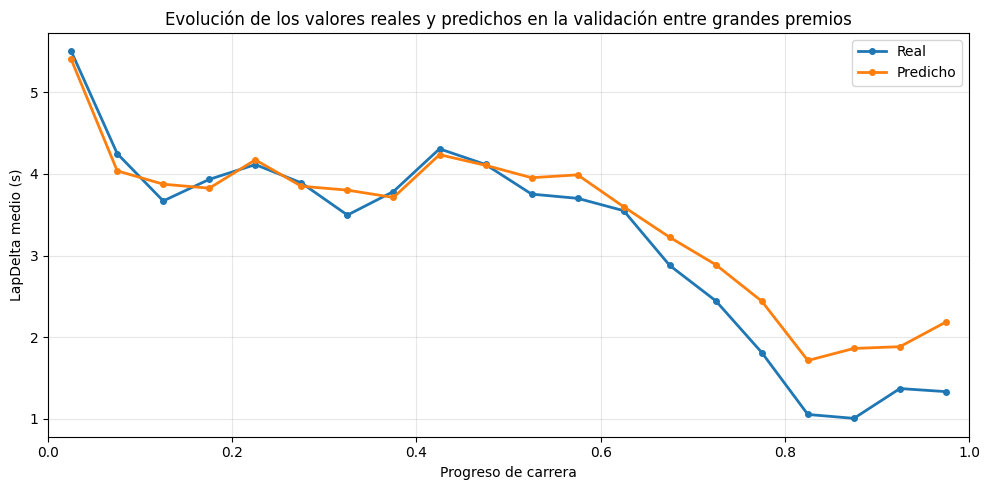

,LapProgressBin,LapDelta_real,LapDelta_predicho,RaceProgress
0,0,5.503,5.403,0.025
1,1,4.248,4.037,0.075
2,2,3.668,3.873,0.125
3,3,3.933,3.825,0.175
4,4,4.114,4.172,0.225
5,5,3.889,3.849,0.275
6,6,3.496,3.801,0.325
7,7,3.784,3.711,0.375
8,8,4.307,4.235,0.425
9,9,4.115,4.105,0.475


In [45]:
#Evolución de los valores reales y predichos en la validación entre grandes premios

pred_validacion = []

for driver_code in drivers_to_analyze:
    df_driver = df_validation[df_validation["Driver"] == driver_code]
    gps = df_driver["GP_file"].value_counts()
    gps = gps[gps >= 20].index

    for test_gp in gps:
        train_df = df_driver[df_driver["GP_file"] != test_gp]
        test_df = df_driver[df_driver["GP_file"] == test_gp]

        if len(train_df) < 100:
            continue

        model = Pipeline([("prep", create_preprocessor()), ("model", create_models()[best_model_validation])])
        model.fit(train_df[base_features], train_df["LapDelta"])
        y_pred = model.predict(test_df[base_features])

        pred_validacion.append(pd.DataFrame({"LapProgress": test_df["LapProgress"].values, "LapDelta_real": test_df["LapDelta"].values, "LapDelta_predicho": y_pred}))

pred_validacion_df = pd.concat(pred_validacion, ignore_index=True)
pred_validacion_df["LapProgressBin"] = pd.cut(pred_validacion_df["LapProgress"], bins=np.linspace(0, 1, 21), labels=False, include_lowest=True)

curva_validacion = pred_validacion_df.groupby("LapProgressBin")[["LapDelta_real", "LapDelta_predicho"]].mean().reset_index()
curva_validacion["RaceProgress"] = (curva_validacion["LapProgressBin"] + 0.5) / 20

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(curva_validacion["RaceProgress"], curva_validacion["LapDelta_real"], marker="o", markersize=4, linewidth=2, label="Real")
ax.plot(curva_validacion["RaceProgress"], curva_validacion["LapDelta_predicho"], marker="o", markersize=4, linewidth=2, label="Predicho")
ax.set_title("Evolución de los valores reales y predichos en la validación entre grandes premios")
ax.set_xlabel("Progreso de carrera")
ax.set_ylabel("LapDelta medio (s)")
ax.set_xlim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(curva_validacion.round(3))

#### Importancia de las variables en la validación entre grandes premios

In [46]:
#Importancia de variables en la validación entre grandes premios

importance_validation = []

for driver_code, driver_name_val in validation_results_df[["Driver_code", "Driver"]].drop_duplicates().itertuples(index=False):
    best_model_name = mejores_validacion.loc[mejores_validacion["Driver"] == driver_name_val, "Model"].iloc[0]
    df_driver = df_validation[df_validation["Driver"] == driver_code]

    for test_gp in validation_results_df.loc[validation_results_df["Driver_code"] == driver_code, "Test_GP"].unique():
        train_df = df_driver[df_driver["GP_file"] != test_gp]
        test_df = df_driver[df_driver["GP_file"] == test_gp]

        model_imp = Pipeline([("prep", create_preprocessor()), ("model", create_models()[best_model_name])])
        model_imp.fit(train_df[base_features], train_df["LapDelta"])

        perm = permutation_importance(model_imp, test_df[base_features], test_df["LapDelta"], n_repeats=10, random_state=42, scoring="r2", n_jobs=-1)

        for variable, importance in zip(base_features, perm.importances_mean):
            importance_validation.append({"Driver": driver_name_val, "Test_GP": test_gp, "Variable": variable, "Importancia": importance})

importance_validation_df = pd.DataFrame(importance_validation)
importance_driver = importance_validation_df.groupby(["Driver", "Variable"])["Importancia"].median().reset_index()

importance_validation_summary = importance_driver.groupby("Variable")["Importancia"].agg(Q25=lambda x: x.quantile(.25), Mediana="median", Q75=lambda x: x.quantile(.75)).reset_index()

display(importance_validation_summary.sort_values("Mediana", ascending=False).reset_index(drop=True).round(3))

,Variable,Q25,Mediana,Q75
0,TyreLife,0.451,1.082,1.341
1,LapProgress,0.124,0.211,0.290
2,TyreDeg,0.015,0.106,0.252
3,Compound,0.011,0.020,0.041
4,Stint,0.001,0.010,0.031


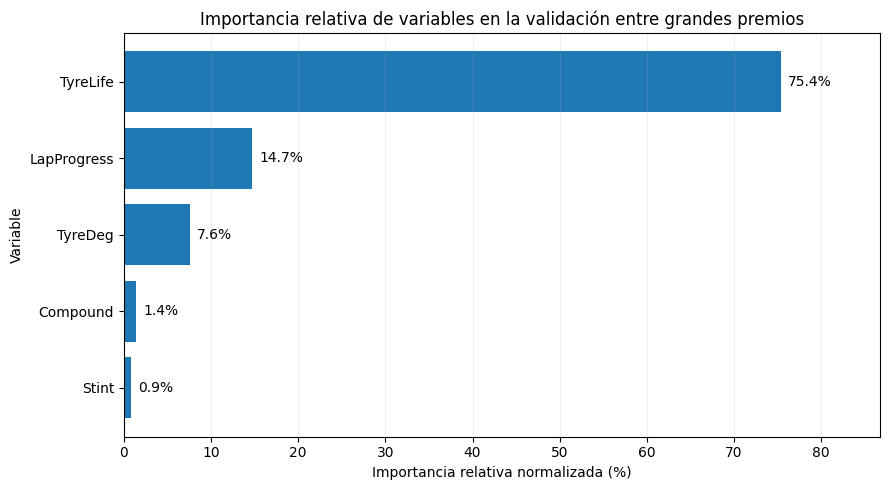

In [47]:
#Importancia de variables en la validación entre grandes premios

pilotos_imp = mejores_validacion.loc[mejores_validacion["N_GP"] >= 5, "Driver"]
imp_val = importance_driver[importance_driver["Driver"].isin(pilotos_imp)].groupby("Variable")["Importancia"].median().clip(lower=0)
imp_val = (100 * imp_val / imp_val.sum()).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(imp_val.index, imp_val.values)

for bar, value in zip(bars, imp_val.values):
    ax.text(value + 0.8, bar.get_y() + bar.get_height()/2, f"{value:.1f}%", va="center", fontsize=10)

ax.set_xlim(0, imp_val.max() * 1.15)
ax.set_title("Importancia relativa de variables en la validación entre grandes premios")
ax.set_xlabel("Importancia relativa normalizada (%)")
ax.set_ylabel("Variable")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

In [48]:
#Importancia de las variables por piloto en la validación entre grandes premios

importancia_validacion = importance_driver.pivot(index="Driver", columns="Variable", values="Importancia").sort_values("TyreLife", ascending=False).reset_index().rename_axis(None, axis=1)
display(importancia_validacion.style.hide(axis="index").format(precision=3))

Driver,Compound,LapProgress,Stint,TyreDeg,TyreLife
Charles Leclerc,0.005,0.158,0.023,1.051,2.340
Nico Hulkenberg,0.025,0.240,0.000,0.217,1.635
Franco Colapinto,0.014,0.300,0.225,0.068,1.611
Carlos Sainz,0.041,0.281,0.066,0.288,1.518
Kevin Magnussen,0.005,0.169,0.075,0.110,1.435
Max Verstappen,0.020,0.047,0.106,0.004,1.389
Sergio Perez,0.042,0.107,0.007,0.011,1.293
Pierre Gasly,0.000,0.211,0.000,0.000,1.236
Alexander Albon,0.005,0.075,0.006,0.006,1.164
Yuki Tsunoda,0.091,0.208,0.022,0.024,1.125


### Modelo global
Se entrena un modelo utilizando conjuntamente las vueltas de todos los pilotos e incorporando la variable Driver como predictora. El objetivo es comprobar si utilizar la información de toda la parrilla mejora la capacidad de generalización.

Posteriormente, el modelo global se compara con los modelos específicos por piloto utilizando las mismas combinaciones de piloto y gran premio disponibles en ambos procedimientos.

#### Ejecución del modelo global

Se entrena el modelo global sobre todos los pilotos, incorporando el piloto como variable, y se valida dejando fuera cada gran premio de forma sucesiva. Además del rendimiento sobre el gran premio completo, se calculan las métricas de cada piloto cuando dispone de al menos 20 vueltas en el conjunto de test.

In [49]:
#Modelo global

global_df = df.copy()
global_results = []
gps = global_df["GP_file"].value_counts()[lambda x: x >= 60].index

for test_gp in gps:
    train_df = global_df[global_df["GP_file"] != test_gp]
    test_df = global_df[global_df["GP_file"] == test_gp]

    if len(train_df) < 300:
        continue

    X_train_global = train_df[global_features]
    y_train_global = train_df["LapDelta"]
    X_test_global = test_df[global_features]
    y_test_global = test_df["LapDelta"]

    for model_name, estimator in create_models().items():
        model_global = Pipeline([("prep", create_preprocessor(include_driver=True)), ("model", estimator)])
        model_global.fit(X_train_global, y_train_global)
        y_pred_global = model_global.predict(X_test_global)

        per_driver_r2 = {}
        per_driver_mae = {}
        per_driver_rmse = {}

        for drv in test_df["Driver"].unique():
            mask = (test_df["Driver"] == drv).values

            if mask.sum() >= 20:
                driver = driver_names.get(drv, drv)
                per_driver_r2[driver] = r2_score(y_test_global[mask], y_pred_global[mask])
                per_driver_mae[driver] = mean_absolute_error(y_test_global[mask], y_pred_global[mask])
                per_driver_rmse[driver] = np.sqrt(mean_squared_error(y_test_global[mask], y_pred_global[mask]))

        global_results.append({"Test_GP": test_gp, "Model": model_name, "MAE": mean_absolute_error(y_test_global, y_pred_global), "RMSE": np.sqrt(mean_squared_error(y_test_global, y_pred_global)), "R2": r2_score(y_test_global, y_pred_global), "R2_por_piloto": per_driver_r2, "MAE_por_piloto": per_driver_mae, "RMSE_por_piloto": per_driver_rmse})

global_results_df = pd.DataFrame(global_results)

global_driver_results_df = pd.DataFrame([
    {"Test_GP": row["Test_GP"], "Model": row["Model"], "Driver": driver, "R2": r2, "MAE": row["MAE_por_piloto"][driver], "RMSE": row["RMSE_por_piloto"][driver]}
    for _, row in global_results_df.iterrows()
    for driver, r2 in row["R2_por_piloto"].items()
])

#### Resultados numéricos
Se resume primero el rendimiento de los cuatro modelos globales sobre los grandes premios completos y se selecciona como modelo global de referencia para posteriores análisis el que obtiene el mayor R2 mediano. A continuación, se obtiene el rendimiento de ese modelo por piloto y se realiza un resumen estadístico de sus métricas.

In [50]:
#Resultados generales de los modelos globales

global_summary = global_results_df.groupby("Model").agg(MAE_med=("MAE", "median"), RMSE_med=("RMSE", "median"), R2_med=("R2", "median"), R2_mean=("R2", "mean"), R2_std=("R2", "std"), R2_q25=("R2", lambda x: x.quantile(.25)), R2_q75=("R2", lambda x: x.quantile(.75)), N_GP=("R2", "count")).reset_index().sort_values("R2_med", ascending=False).reset_index(drop=True)
best_global_model_name = global_summary.iloc[0]["Model"]

display(global_summary.round(3))

,Model,MAE_med,RMSE_med,R2_med,R2_mean,R2_std,R2_q25,R2_q75,N_GP
0,HistGradientBoosting,1.320,2.306,0.509,0.242,0.898,0.281,0.640,24
1,GradientBoosting,1.319,2.307,0.507,0.311,0.698,0.326,0.659,24
2,RandomForest,1.653,3.094,0.324,-0.088,1.409,-0.179,0.527,24
3,Ridge,1.893,3.715,0.048,-0.129,0.609,-0.004,0.089,24


In [51]:
#Resultados del modelo global seleccionado por piloto

mejor_global = global_driver_results_df[global_driver_results_df["Model"] == best_global_model_name].groupby("Driver").agg(R2_med=("R2", "median"), R2_q25=("R2", lambda x: x.quantile(.25)), R2_q75=("R2", lambda x: x.quantile(.75)), MAE_med=("MAE", "median"), RMSE_med=("RMSE", "median"), N_GP=("R2", "count")).reset_index().sort_values("R2_med", ascending=False).reset_index(drop=True)

display(mejor_global.round(3))

,Driver,R2_med,R2_q25,R2_q75,MAE_med,RMSE_med,N_GP
0,Franco Colapinto,0.803,0.557,0.843,1.033,1.458,8
1,Jack Doohan,0.791,0.791,0.791,1.017,1.358,1
2,Sergio Perez,0.678,0.080,0.785,1.220,1.907,22
3,Alexander Albon,0.585,-0.067,0.763,1.436,1.933,20
4,Carlos Sainz,0.584,0.315,0.798,1.136,1.883,23
5,Max Verstappen,0.564,-0.016,0.791,1.267,1.948,23
6,Nico Hulkenberg,0.555,0.245,0.779,1.416,2.055,23
7,Valtteri Bottas,0.552,0.120,0.681,1.559,2.371,23
8,Pierre Gasly,0.524,-0.083,0.815,1.660,2.184,21
9,Kevin Magnussen,0.490,0.304,0.820,1.353,1.958,21


In [52]:
#Resumen estadístico del modelo global seleccionado

resumen_estadistico_global = mejor_global[["R2_med", "MAE_med", "RMSE_med"]].rename(columns={"R2_med":"R2", "MAE_med":"MAE", "RMSE_med":"RMSE"}).describe()

resumen_estadistico_global = resumen_estadistico_global.rename(index={
    "count":"N",
    "mean":"Media",
    "std":"Desviación estándar",
    "min":"Mínimo",
    "25%":"Percentil 25",
    "50%":"Mediana",
    "75%":"Percentil 75",
    "max":"Máximo"
})

display(resumen_estadistico_global.round(3))

,R2,MAE,RMSE
N,24.000,24.000,24.000
Media,0.474,1.450,2.313
Desviación estándar,0.157,0.263,0.544
Mínimo,0.123,1.017,1.358
Percentil 25,0.388,1.256,1.944
Mediana,0.481,1.439,2.258
Percentil 75,0.558,1.627,2.686
Máximo,0.803,1.950,3.882


In [53]:
# Mejor modelo global por piloto

global_driver_summary = global_driver_results_df.groupby(["Driver", "Model"]).agg(P25=("R2", lambda x: x.quantile(.25)), R2=("R2", "median"), P75=("R2", lambda x: x.quantile(.75)), MAE=("MAE", "median"), RMSE=("RMSE", "median"), N_GP=("R2", "count")).reset_index()
resumen_global_piloto = global_driver_summary.loc[global_driver_summary.groupby("Driver")["R2"].idxmax()].sort_values("R2", ascending=False).reset_index(drop=True)

display(resumen_global_piloto.round(3))
display(resumen_global_piloto["Model"].value_counts().rename("N_pilotos"))

,Driver,Model,P25,R2,P75,MAE,RMSE,N_GP
0,Franco Colapinto,HistGradientBoosting,0.557,0.803,0.843,1.033,1.458,8
1,Jack Doohan,HistGradientBoosting,0.791,0.791,0.791,1.017,1.358,1
2,Pierre Gasly,GradientBoosting,-0.006,0.678,0.832,1.352,2.030,21
3,Sergio Perez,HistGradientBoosting,0.080,0.678,0.785,1.220,1.907,22
4,Kevin Magnussen,GradientBoosting,0.321,0.640,0.835,1.218,1.675,21
5,Nico Hulkenberg,GradientBoosting,0.310,0.630,0.789,1.377,1.984,23
6,Carlos Sainz,GradientBoosting,0.304,0.620,0.789,1.250,1.928,23
7,Alexander Albon,HistGradientBoosting,-0.067,0.585,0.763,1.436,1.933,20
8,Oliver Bearman,GradientBoosting,-0.261,0.583,0.685,1.462,1.875,3
9,Max Verstappen,GradientBoosting,0.081,0.583,0.797,1.308,1.758,23


Model
GradientBoosting        15
HistGradientBoosting     9
Name: N_pilotos, dtype: int64

In [54]:
# R2 mediano de cada modelo global por piloto

r2_global_piloto = global_driver_summary.pivot(index="Driver", columns="Model", values="R2")[model_order].reset_index().rename_axis(None, axis=1)

display(r2_global_piloto.style.hide(axis="index").format(precision=3))

Driver,Ridge,RandomForest,GradientBoosting,HistGradientBoosting
Alexander Albon,-0.000,-0.021,0.553,0.585
Carlos Sainz,0.043,0.354,0.620,0.584
Charles Leclerc,0.058,0.326,0.496,0.481
Daniel Ricciardo,-0.099,0.066,0.158,0.254
Esteban Ocon,-0.051,0.359,0.568,0.481
Fernando Alonso,0.041,0.280,0.325,0.375
Franco Colapinto,0.001,0.580,0.767,0.803
George Russell,0.050,0.353,0.467,0.443
Guanyu Zhou,0.036,0.270,0.399,0.356
Jack Doohan,-0.003,0.646,0.786,0.791


#### Visualización de resultados
Se representan gráficamente los principales resultados obtenidos con el modelo global.

##### Comparación del rendimiento de los modelos globales

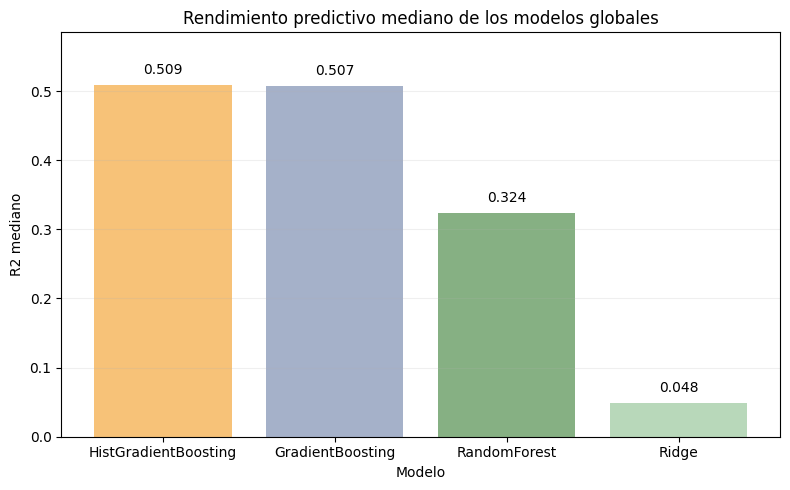

In [55]:
#Comparación del rendimiento de los modelos globales

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(global_summary["Model"], global_summary["R2_med"], color=global_summary["Model"].map(color_map))

for bar, r2 in zip(bars, global_summary["R2_med"]):
    ax.text(bar.get_x() + bar.get_width()/2, r2 + 0.012, f"{r2:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Rendimiento predictivo mediano de los modelos globales")
ax.set_xlabel("Modelo")
ax.set_ylabel("R2 mediano")
ax.set_ylim(0, global_summary["R2_med"].max()*1.15)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

##### Mejor rendimiento predictivo del modelo global por piloto

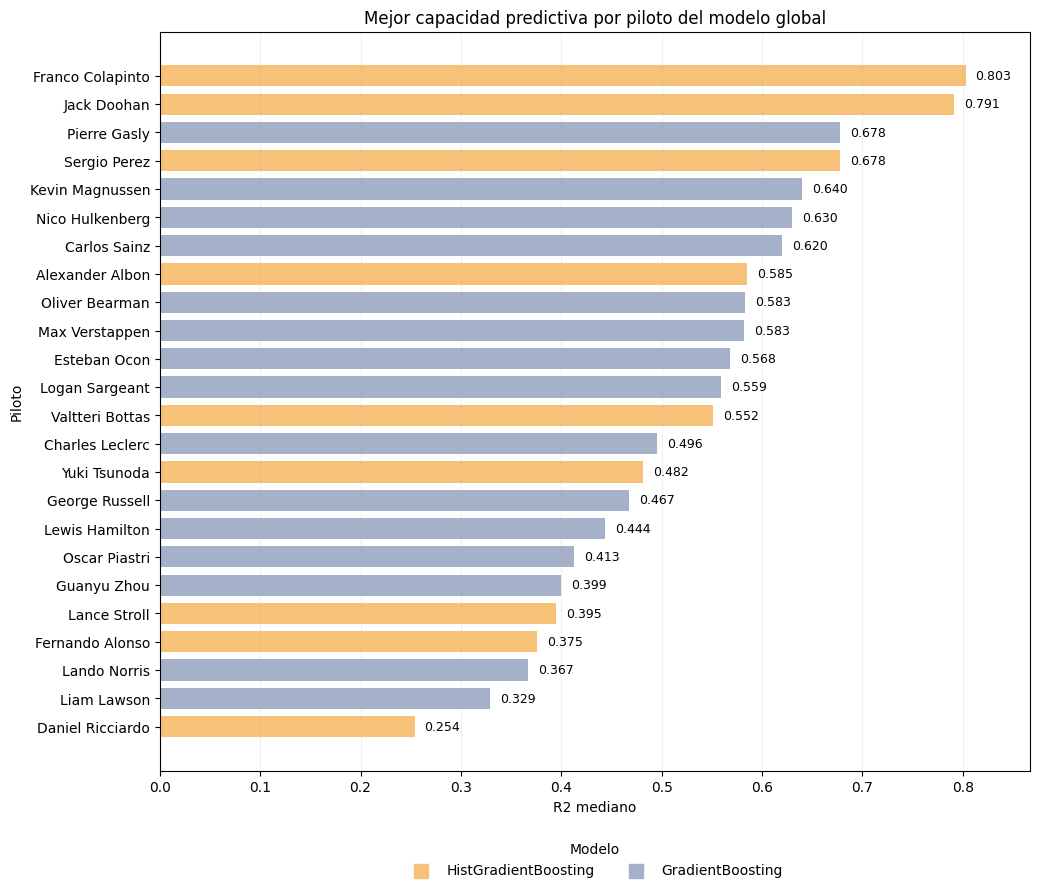

In [56]:
#Mejor rendimiento predictivo del modelo global por piloto

plot_global_driver = resumen_global_piloto.sort_values("R2").reset_index(drop=True)
y = np.arange(len(plot_global_driver))

fig, ax = plt.subplots(figsize=(10.5,9))
bars = ax.barh(y, plot_global_driver["R2"], color=plot_global_driver["Model"].map(color_map), height=0.75)

ax.set_yticks(y)
ax.set_yticklabels(plot_global_driver["Driver"])

for bar, r2 in zip(bars, plot_global_driver["R2"]):
    ax.text(r2 + 0.01, bar.get_y() + bar.get_height()/2, f"{r2:.3f}", va="center", ha="left", fontsize=9)

for model in plot_global_driver["Model"].unique():
    ax.scatter([], [], marker="s", s=90, color=color_map[model], label=model)

ax.set_title("Mejor capacidad predictiva por piloto del modelo global")
ax.set_xlabel("R2 mediano")
ax.set_ylabel("Piloto")
ax.set_xlim(0, plot_global_driver["R2"].max()*1.08)
ax.grid(axis="x", alpha=0.2)
ax.legend(title="Modelo", ncol=3, loc="upper center", bbox_to_anchor=(0.5,-0.08), frameon=False)
plt.tight_layout()
plt.show()

##### Rendimiento del modelo global por piloto y gran premio

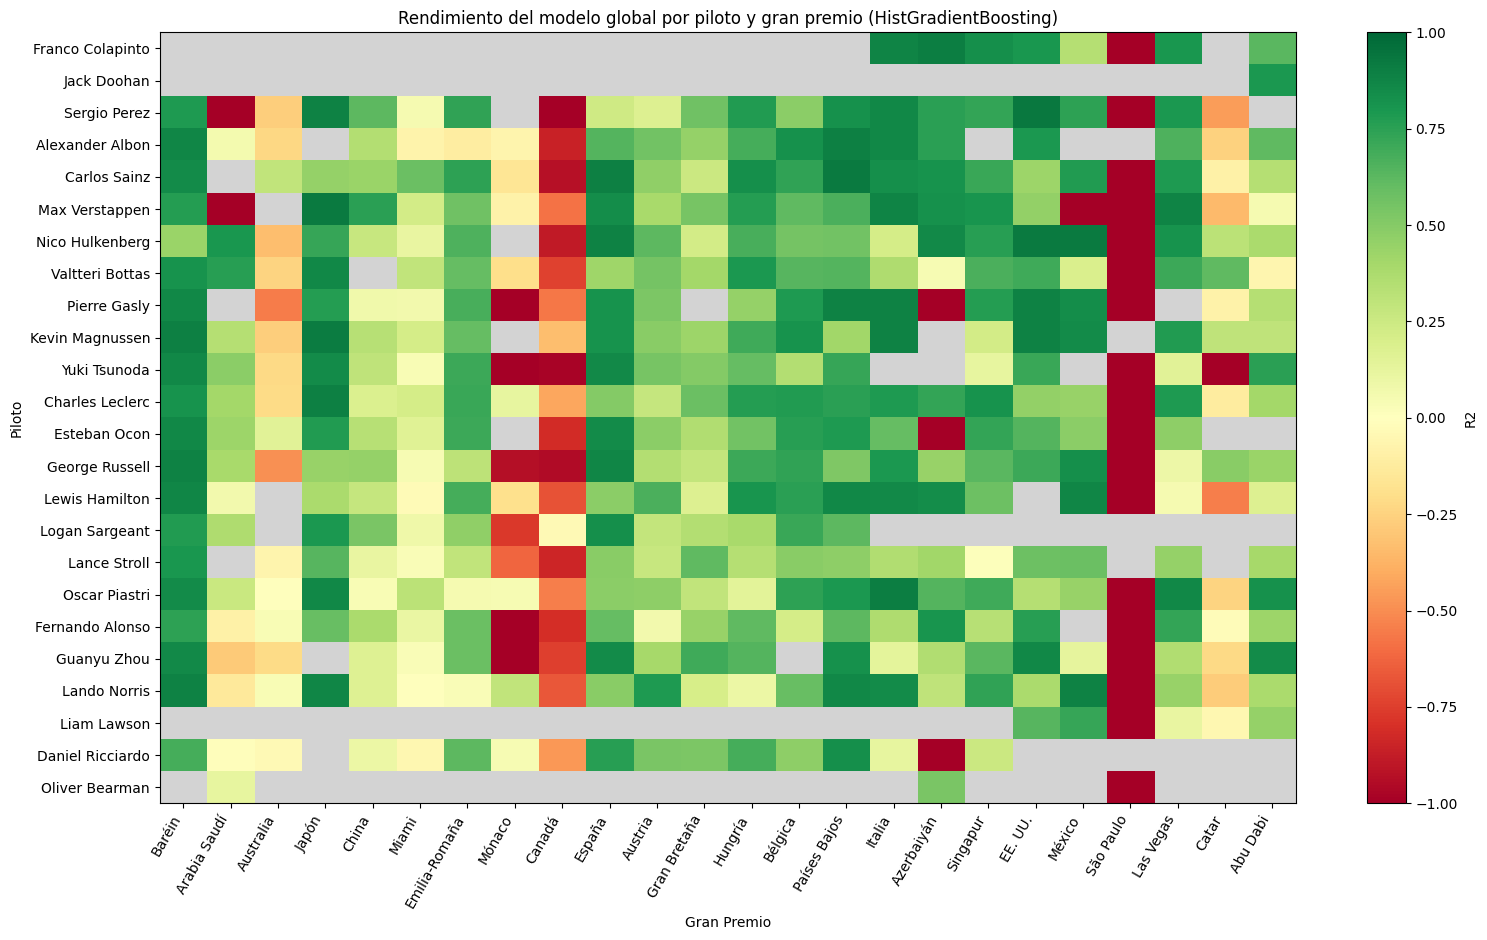

In [57]:
#Rendimiento del modelo global por piloto y Gran Premio

r2_driver_gp = global_driver_results_df[global_driver_results_df["Model"] == best_global_model_name]
pilotos_heat = mejor_global["Driver"].tolist()
heat = r2_driver_gp.pivot(index="Driver", columns="Test_GP", values="R2").reindex(index=pilotos_heat, columns=gp_order)

fig, ax = plt.subplots(figsize=(16,9.5))
cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("lightgray")

im = ax.imshow(heat, aspect="auto", cmap=cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(gp_order)))
ax.set_xticklabels([gp_labels_val[gp] for gp in gp_order], rotation=60, ha="right")
ax.set_yticks(range(len(pilotos_heat)))
ax.set_yticklabels(pilotos_heat)

fig.colorbar(im, ax=ax, label="R2")
ax.set_title(f"Rendimiento del modelo global por piloto y gran premio ({best_global_model_name})")
ax.set_xlabel("Gran Premio")
ax.set_ylabel("Piloto")
plt.tight_layout()
plt.show()

In [58]:
#R2 del modelo global por piloto y Gran Premio

heat_anexo = heat.copy()
heat_anexo.columns = heat_anexo.columns.str.replace("_Grand_Prix", "", regex=False).str.replace("_", " ", regex=False)
heat_anexo = heat_anexo.reset_index().rename_axis(None, axis=1)

display(heat_anexo.iloc[:, :13].style.hide(axis="index").format(precision=3, na_rep="--"))
display(pd.concat([heat_anexo[["Driver"]], heat_anexo.iloc[:, 13:]], axis=1).style.hide(axis="index").format(precision=3, na_rep="--"))

Driver,Bahrain,Saudi Arabian,Australian,Japanese,Chinese,Miami,Emilia Romagna,Monaco,Canadian,Spanish,Austrian,British
Franco Colapinto,--,--,--,--,--,--,--,--,--,--,--,--
Jack Doohan,--,--,--,--,--,--,--,--,--,--,--,--
Sergio Perez,0.788,-1.782,-0.273,0.886,0.623,0.049,0.735,--,-1.116,0.239,0.174,0.564
Alexander Albon,0.872,0.059,-0.234,--,0.345,-0.077,-0.110,-0.063,-0.856,0.644,0.555,0.448
Carlos Sainz,0.846,--,0.293,0.446,0.432,0.584,0.744,-0.161,-0.928,0.894,0.462,0.253
Max Verstappen,0.766,-1.614,--,0.918,0.756,0.220,0.564,-0.084,-0.582,0.839,0.383,0.541
Nico Hulkenberg,0.432,0.798,-0.334,0.725,0.271,0.113,0.663,--,-0.884,0.891,0.625,0.219
Valtteri Bottas,0.817,0.763,-0.248,0.862,--,0.294,0.599,-0.198,-0.737,0.420,0.552,0.401
Pierre Gasly,0.860,--,-0.552,0.766,0.071,0.068,0.673,-1.194,-0.568,0.815,0.524,--
Kevin Magnussen,0.894,0.337,-0.267,0.913,0.329,0.215,0.597,--,-0.334,0.820,0.490,0.429


Driver,Hungarian,Belgian,Dutch,Italian,Azerbaijan,Singapore,United States,Mexico City,São Paulo,Las Vegas,Qatar,Abu Dhabi
Franco Colapinto,--,--,--,0.881,0.904,0.831,0.803,0.339,-5.838,0.802,--,0.630
Jack Doohan,--,--,--,--,--,--,--,--,--,--,--,0.791
Sergio Perez,0.776,0.481,0.828,0.865,0.753,0.733,0.922,0.745,-2.683,0.797,-0.448,--
Alexander Albon,0.680,0.824,0.892,0.861,0.753,--,0.792,--,--,0.664,-0.254,0.615
Carlos Sainz,0.828,0.735,0.919,0.833,0.813,0.711,0.425,0.778,-2.669,0.783,-0.093,0.338
Max Verstappen,0.771,0.615,0.669,0.881,0.824,0.811,0.455,-1.248,-8.584,0.876,-0.347,0.051
Nico Hulkenberg,0.676,0.549,0.555,0.212,0.857,0.760,0.915,0.918,-9.209,0.816,0.314,0.375
Valtteri Bottas,0.791,0.640,0.648,0.361,0.047,0.665,0.697,0.194,-1.581,0.705,0.610,-0.062
Pierre Gasly,0.453,0.786,0.884,0.890,-2.566,0.769,0.886,0.839,-5.255,--,-0.083,0.336
Kevin Magnussen,0.701,0.817,0.412,0.884,--,0.223,0.886,0.851,--,0.780,0.298,0.304


##### Rendimiento del modelo global por gran premio según las condiciones de carrera

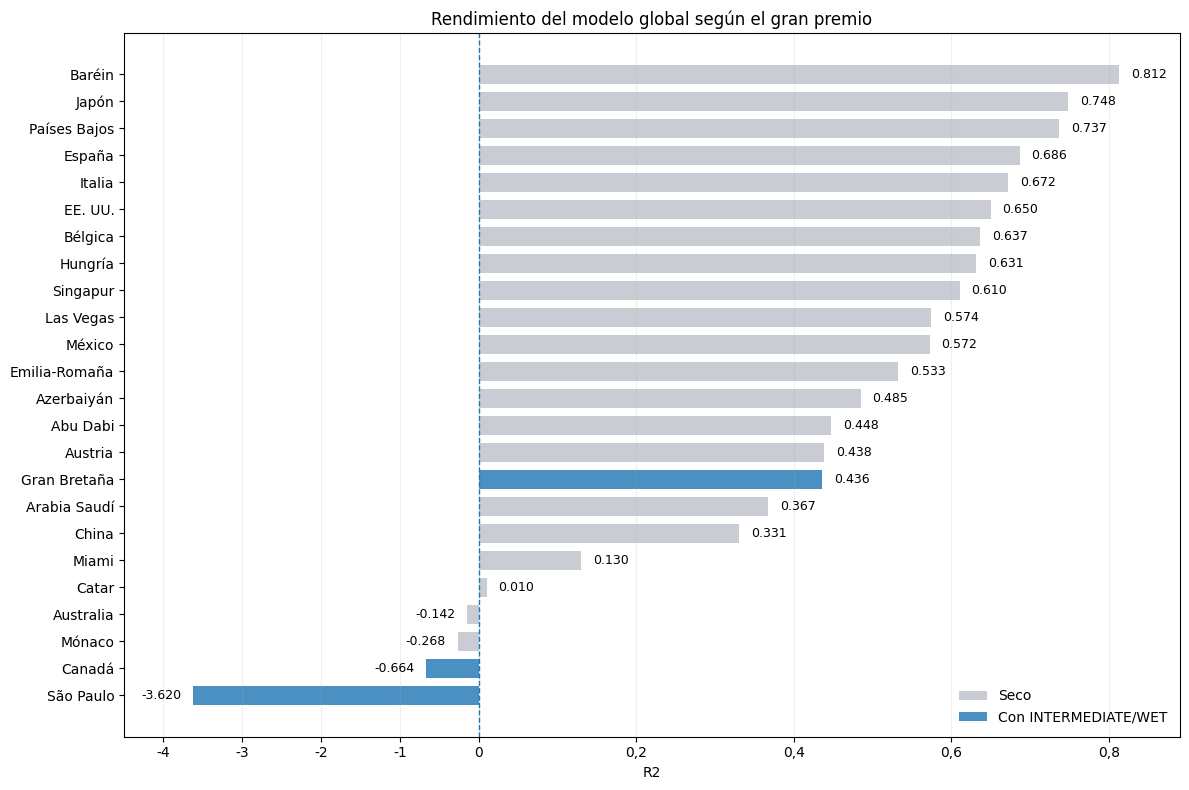

In [59]:
#Rendimiento del modelo global por Gran Premio según las condiciones de carrera

plot_gp = global_results_df[global_results_df["Model"] == best_global_model_name][["Test_GP", "R2"]].merge(wet_info_val, left_on="Test_GP", right_on="GP_file")
plot_gp["GP"] = plot_gp["Test_GP"].replace(gp_labels_val)
plot_gp = plot_gp.sort_values("R2").reset_index(drop=True)
plot_gp["R2_plot"] = np.where(plot_gp["R2"] < 0, plot_gp["R2"] / 10, plot_gp["R2"])

fig, ax = plt.subplots(figsize=(12,8))
bars = ax.barh(plot_gp["GP"], plot_gp["R2_plot"], color=np.where(plot_gp["Condiciones_humedas"], "#4A90C2", "#C9CDD3"), height=0.7)

for bar, r2, x in zip(bars, plot_gp["R2"], plot_gp["R2_plot"]):
    ax.text(x + (0.015 if r2 >= 0 else -0.015), bar.get_y() + bar.get_height()/2, f"{r2:.3f}", va="center", ha="left" if r2 >= 0 else "right", fontsize=9)

ticks = np.array([-4,-3,-2,-1,0,0.2,0.4,0.6,0.8,1])
ax.set_xticks(np.where(ticks < 0, ticks / 10, ticks))
ax.set_xticklabels(["-4","-3","-2","-1","0","0,2","0,4","0,6","0,8","1"])
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Rendimiento del modelo global según el gran premio")
ax.set_xlabel("R2")
ax.set_ylabel("")
ax.set_xlim(-0.45,0.89)
ax.grid(axis="x", alpha=0.2)
ax.legend(handles=[Patch(facecolor="#C9CDD3", label="Seco"), Patch(facecolor="#4A90C2", label="Con INTERMEDIATE/WET")], frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

##### Evolución de los valores reales y predichos del modelo global

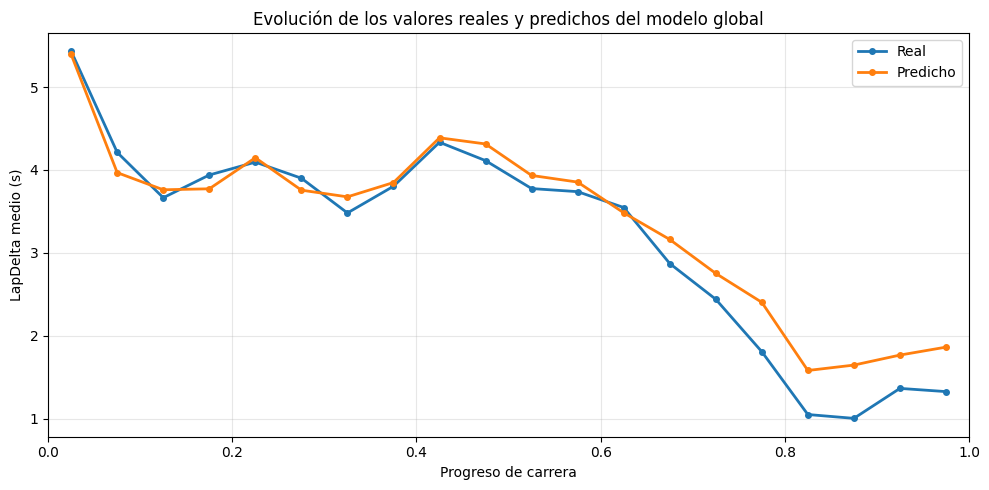

,LapProgressBin,LapDelta_real,LapDelta_predicho,RaceProgress
0,0,5.432,5.393,0.025
1,1,4.212,3.968,0.075
2,2,3.666,3.761,0.125
3,3,3.939,3.773,0.175
4,4,4.095,4.147,0.225
5,5,3.901,3.757,0.275
6,6,3.482,3.676,0.325
7,7,3.803,3.848,0.375
8,8,4.334,4.388,0.425
9,9,4.113,4.314,0.475


In [60]:
#Evolución de los valores reales y predichos del modelo global

pred_global = []

for test_gp in global_df["GP_file"].value_counts()[lambda x: x >= 60].index:
    train_df = global_df[global_df["GP_file"] != test_gp]
    test_df = global_df[global_df["GP_file"] == test_gp]

    if len(train_df) < 300:
        continue

    model = Pipeline([("prep", create_preprocessor(include_driver=True)), ("model", create_models()[best_global_model_name])])
    model.fit(train_df[global_features], train_df["LapDelta"])
    y_pred = model.predict(test_df[global_features])

    pred_global.append(pd.DataFrame({"LapProgress": test_df["LapProgress"].values, "LapDelta_real": test_df["LapDelta"].values, "LapDelta_predicho": y_pred}))

pred_global_df = pd.concat(pred_global, ignore_index=True)
pred_global_df["LapProgressBin"] = pd.cut(pred_global_df["LapProgress"], bins=np.linspace(0,1,21), labels=False, include_lowest=True)
curva_global = pred_global_df.groupby("LapProgressBin")[["LapDelta_real", "LapDelta_predicho"]].mean().reset_index()
curva_global["RaceProgress"] = (curva_global["LapProgressBin"] + 0.5) / 20

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(curva_global["RaceProgress"], curva_global["LapDelta_real"], marker="o", markersize=4, linewidth=2, label="Real")
ax.plot(curva_global["RaceProgress"], curva_global["LapDelta_predicho"], marker="o", markersize=4, linewidth=2, label="Predicho")
ax.set_title("Evolución de los valores reales y predichos del modelo global")
ax.set_xlabel("Progreso de carrera")
ax.set_ylabel("LapDelta medio (s)")
ax.set_xlim(0,1)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(curva_global.round(3))

##### Importancia de variables del modelo global

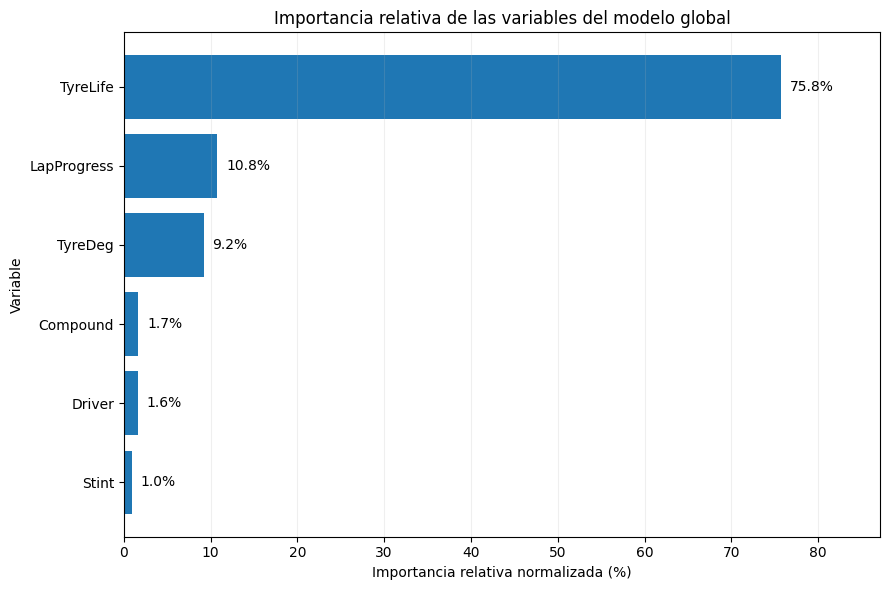

,Variable,Percentil_25,Mediana,Percentil_75
0,TyreLife,0.387,0.904,1.136
1,LapProgress,0.073,0.129,0.173
2,TyreDeg,0.043,0.110,0.189
3,Compound,0.002,0.020,0.052
4,Driver,0.006,0.019,0.036
5,Stint,0.002,0.011,0.017


In [61]:
#Importancia de las variables del modelo global

importance_results = []

for test_gp in global_df["GP_file"].value_counts()[lambda x: x >= 60].index:
    train_df = global_df[global_df["GP_file"] != test_gp]
    test_df = global_df[global_df["GP_file"] == test_gp]

    model_imp = Pipeline([("prep", create_preprocessor(include_driver=True)), ("model", create_models()[best_global_model_name])])
    model_imp.fit(train_df[global_features], train_df["LapDelta"])

    perm = permutation_importance(model_imp, test_df[global_features], test_df["LapDelta"], n_repeats=10, random_state=42, scoring="r2", n_jobs=-1)

    for variable, importance in zip(global_features, perm.importances_mean):
        importance_results.append({"Test_GP": test_gp, "Variable": variable, "Importancia": importance})

importance_gp_df = pd.DataFrame(importance_results)

imp = importance_gp_df.groupby("Variable")["Importancia"].agg(Percentil_25=lambda x: x.quantile(.25), Mediana="median", Percentil_75=lambda x: x.quantile(.75)).reset_index()
imp["Importancia_pct"] = 100 * imp["Mediana"].clip(lower=0) / imp["Mediana"].clip(lower=0).sum()
imp = imp.sort_values("Importancia_pct")

fig, ax = plt.subplots(figsize=(9,6))
bars = ax.barh(imp["Variable"], imp["Importancia_pct"])

for bar, value in zip(bars, imp["Importancia_pct"]):
    ax.text(value + 1, bar.get_y() + bar.get_height()/2, f"{value:.1f}%", va="center", fontsize=10)

ax.set_xlim(0, imp["Importancia_pct"].max()*1.15)
ax.set_title("Importancia relativa de las variables del modelo global")
ax.set_xlabel("Importancia relativa normalizada (%)")
ax.set_ylabel("Variable")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

display(imp.sort_values("Importancia_pct", ascending=False)[["Variable", "Percentil_25", "Mediana", "Percentil_75"]].reset_index(drop=True).round(3))

In [62]:
#Importancia de las variables del modelo global por Gran Premio

importancia_global_gp = importance_gp_df.pivot(index="Test_GP", columns="Variable", values="Importancia").sort_values("TyreLife", ascending=False).reset_index().rename(columns={"Test_GP":"Gran premio"}).rename_axis(None, axis=1)

display(importancia_global_gp.style.hide(axis="index").format(precision=3))

Gran premio,Compound,Driver,LapProgress,Stint,TyreDeg,TyreLife
Belgian_Grand_Prix,0.010,0.014,0.207,0.046,0.183,1.637
Dutch_Grand_Prix,0.110,0.018,0.296,0.022,0.221,1.460
Bahrain_Grand_Prix,0.011,-0.004,0.070,0.005,0.039,1.362
Japanese_Grand_Prix,0.015,0.000,0.101,-0.006,0.014,1.346
Hungarian_Grand_Prix,0.047,0.057,0.153,0.016,0.206,1.272
Spanish_Grand_Prix,0.051,0.049,0.138,0.009,0.136,1.149
Las_Vegas_Grand_Prix,-0.001,0.062,0.172,0.012,0.011,1.132
United_States_Grand_Prix,0.018,0.021,0.138,0.017,0.057,1.069
Austrian_Grand_Prix,0.072,0.020,0.068,0.018,0.107,1.011
Italian_Grand_Prix,0.022,0.032,0.127,0.014,0.138,0.956


##### Comparación entre modelo global y el mejor modelo específico por piloto

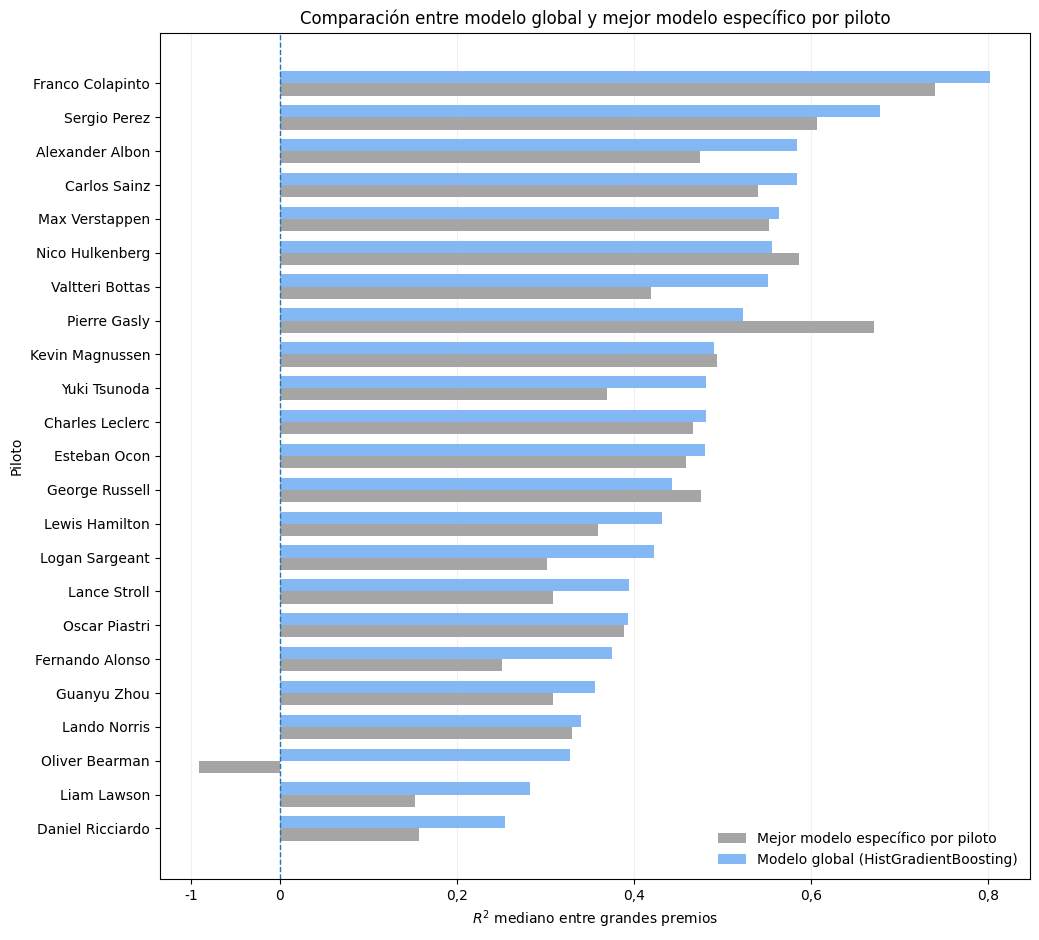

Pilotos comparados: 23
Mejor modelo global: 19
Mejor modelo específico: 4
Diferencia mediana de R2 (global-específico): 0.063


,Driver,Modelo_especifico,R2_global,R2_especifico,Diferencia,N_GP
0,Daniel Ricciardo,GradientBoosting,0.254,0.157,0.097,17
1,Liam Lawson,RandomForest,0.282,0.153,0.130,6
2,Oliver Bearman,HistGradientBoosting,0.328,-0.911,1.239,2
3,Lando Norris,HistGradientBoosting,0.340,0.330,0.010,24
4,Guanyu Zhou,RandomForest,0.356,0.309,0.047,22
5,Fernando Alonso,HistGradientBoosting,0.375,0.250,0.125,23
6,Oscar Piastri,GradientBoosting,0.393,0.388,0.005,24
7,Lance Stroll,HistGradientBoosting,0.395,0.308,0.087,21
8,Logan Sargeant,HistGradientBoosting,0.423,0.302,0.121,14
9,Lewis Hamilton,HistGradientBoosting,0.432,0.359,0.073,22


In [63]:
#Comparación entre modelo global y mejor modelo específico por piloto

gps_comparables = validation_results_df[["Driver", "Test_GP"]].drop_duplicates()
global_comparable = global_driver_results_df[global_driver_results_df["Model"] == best_global_model_name].merge(gps_comparables, on=["Driver", "Test_GP"]).groupby("Driver")["R2"].median().reset_index(name="R2_global")

comparison = global_comparable.merge(mejores_validacion[["Driver", "R2_med", "N_GP"]], on="Driver").rename(columns={"R2_med":"R2_especifico"})
comparison = comparison.sort_values("R2_global").reset_index(drop=True)

r2_global_plot = np.where(comparison["R2_global"] < 0, comparison["R2_global"] / 10, comparison["R2_global"])
r2_especifico_plot = np.where(comparison["R2_especifico"] < 0, comparison["R2_especifico"] / 10, comparison["R2_especifico"])

y = np.arange(len(comparison))
height = 0.36

fig, ax = plt.subplots(figsize=(10.5,9.5))
ax.barh(y-height/2, r2_especifico_plot, height=height, label="Mejor modelo específico por piloto", color="#A5A5A5")
ax.barh(y+height/2, r2_global_plot, height=height, label=f"Modelo global ({best_global_model_name})", color="#84B8F4")

ax.set_yticks(y)
ax.set_yticklabels(comparison["Driver"])

ticks = np.array([-1,0,0.2,0.4,0.6,0.8])
ax.set_xticks(np.where(ticks < 0, ticks / 10, ticks))
ax.set_xticklabels(["-1","0","0,2","0,4","0,6","0,8"])
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Comparación entre modelo global y mejor modelo específico por piloto")
ax.set_xlabel("$R^2$ mediano entre grandes premios")
ax.set_ylabel("Piloto")
ax.grid(axis="x", alpha=0.2)
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

comparison["Diferencia"] = comparison["R2_global"] - comparison["R2_especifico"]
comparison_anexo = comparison.merge(mejores_validacion[["Driver", "Model"]], on="Driver").rename(columns={"Model":"Modelo_especifico"})

print(f"Pilotos comparados: {len(comparison)}")
print(f"Mejor modelo global: {(comparison['Diferencia'] > 0).sum()}")
print(f"Mejor modelo específico: {(comparison['Diferencia'] < 0).sum()}")
print(f"Diferencia mediana de R2 (global-específico): {comparison['Diferencia'].median():.3f}")

display(comparison_anexo[["Driver", "Modelo_especifico", "R2_global", "R2_especifico", "Diferencia", "N_GP"]].round(3))

### Análisis del error del modelo
Se analiza el error de la predicción del modelo global en diferentes situaciones de carrera. Para cada vuelta se calcula el error con signo como la diferencia entre el LapDelta real y el predicho, así como su valor absoluto.

#### Ejecución del modelo
Se repite la validación entre grandes premios con el modelo global seleccionado y se almacenan las predicciones y errores de cada vuelta.

In [64]:
#Análisis del error del modelo global

error_df = df.copy()
error_df["RacePhase"] = pd.cut(error_df["LapProgress"], bins=[0, 0.33, 0.66, 1.01], labels=["Inicio", "Medio", "Final"], include_lowest=True)

error_results = []
gps = error_df["GP_file"].value_counts()[lambda x: x >= 60].index

for test_gp in gps:
    train_df = error_df[error_df["GP_file"] != test_gp]
    test_df = error_df[error_df["GP_file"] == test_gp]

    if len(train_df) < 300:
        continue

    model = Pipeline([("prep", create_preprocessor(include_driver=True)), ("model", create_models()[best_global_model_name])])
    model.fit(train_df[global_features], train_df["LapDelta"])
    y_pred = model.predict(test_df[global_features])

    temp = test_df.copy()
    temp["Predicted_LapDelta"] = y_pred
    temp["Error"] = temp["LapDelta"] - temp["Predicted_LapDelta"]
    temp["Absolute_Error"] = temp["Error"].abs()
    error_results.append(temp)

error_analysis_df = pd.concat(error_results, ignore_index=True)

#### Resultados numéricos
Se obtiene un resumen general del error del modelo y, posteriormente, se agrupan los resultados según la fase de carrera y el compuesto utilizado.

In [65]:
#Resumen general del error

error_summary = pd.DataFrame({
    "MAE": [error_analysis_df["Absolute_Error"].mean()],
    "RMSE": [np.sqrt(np.mean(error_analysis_df["Error"]**2))],
    "Sesgo": [error_analysis_df["Error"].mean()],
    "Percentil_25": [error_analysis_df["Absolute_Error"].quantile(.25)],
    "Mediana": [error_analysis_df["Absolute_Error"].median()],
    "Percentil_75": [error_analysis_df["Absolute_Error"].quantile(.75)],
    "N": [len(error_analysis_df)]
})

display(error_summary.round(3))

,MAE,RMSE,Sesgo,Percentil_25,Mediana,Percentil_75,N
0,2.069,3.958,-0.182,0.46,0.954,1.874,25150


In [66]:
#Error por fase de carrera y compuesto

error_phase_compound = error_analysis_df.groupby(["RacePhase", "Compound"], observed=True).agg(MAE=("Absolute_Error", "mean"), Sesgo=("Error", "mean"), N=("Absolute_Error", "count")).reset_index().sort_values("MAE", ascending=False).reset_index(drop=True).round(3)

display(error_phase_compound)

,RacePhase,Compound,MAE,Sesgo,N
0,Medio,WET,22.860,22.860,3
1,Inicio,WET,15.877,15.877,15
2,Final,INTERMEDIATE,11.423,-9.135,431
3,Inicio,INTERMEDIATE,10.561,0.162,800
4,Medio,INTERMEDIATE,5.633,-0.751,711
5,Medio,SOFT,2.757,-0.008,83
6,Medio,MEDIUM,2.243,0.006,2232
7,Final,MEDIUM,1.855,-0.053,1794
8,Inicio,HARD,1.808,0.168,2285
9,Final,SOFT,1.761,-0.120,791


#### Visualización de resultados
Se representa gráficamente el error del modelo global según distintos factores de carrera, como el compuesto, la fase de carrera, la antigüedad del neumático, el inicio de stint, el piloto y el gran premio.

##### Error del modelo según el compuesto

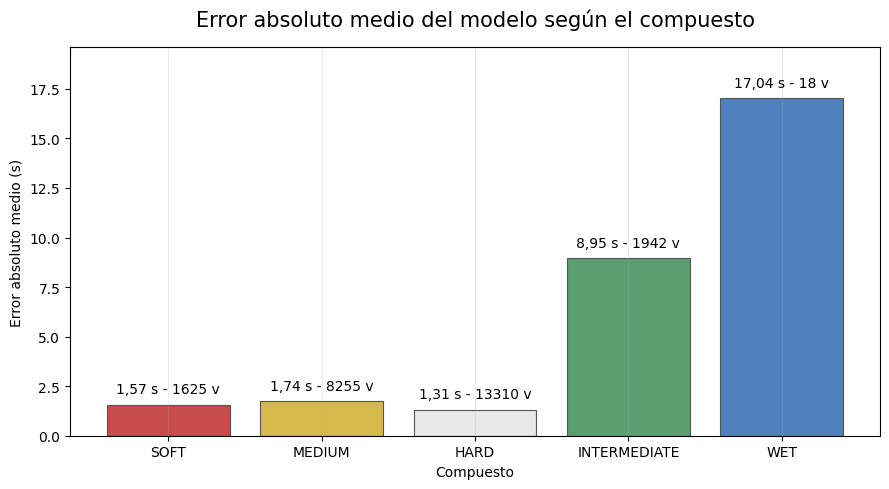

In [67]:
#Error del modelo según el compuesto

compound_order = ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"]
compound_colors = {"SOFT": "#C94C4C", "MEDIUM": "#D6B84B", "HARD": "#E8E8E8", "INTERMEDIATE": "#5B9E6F", "WET": "#4F81BD"}

compound_error = error_analysis_df[error_analysis_df["Compound"].isin(compound_order)].groupby("Compound").agg(MAE=("Absolute_Error", "mean"), N=("Absolute_Error", "size")).reindex(compound_order).dropna().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(compound_error["Compound"], compound_error["MAE"], color=[compound_colors[c] for c in compound_error["Compound"]], edgecolor="#555555", linewidth=0.8)

for bar, mae, n in zip(bars, compound_error["MAE"], compound_error["N"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + compound_error["MAE"].max()*0.025, f"{mae:.2f} s - {n} v".replace(".", ","), ha="center", va="bottom", fontsize=10)

ax.set_title("Error absoluto medio del modelo según el compuesto", fontsize=15, pad=15)
ax.set_ylabel("Error absoluto medio (s)")
ax.set_xlabel("Compuesto")
ax.set_ylim(0, compound_error["MAE"].max()*1.15)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

##### Error del modelo según fase de la carrera y compuesto

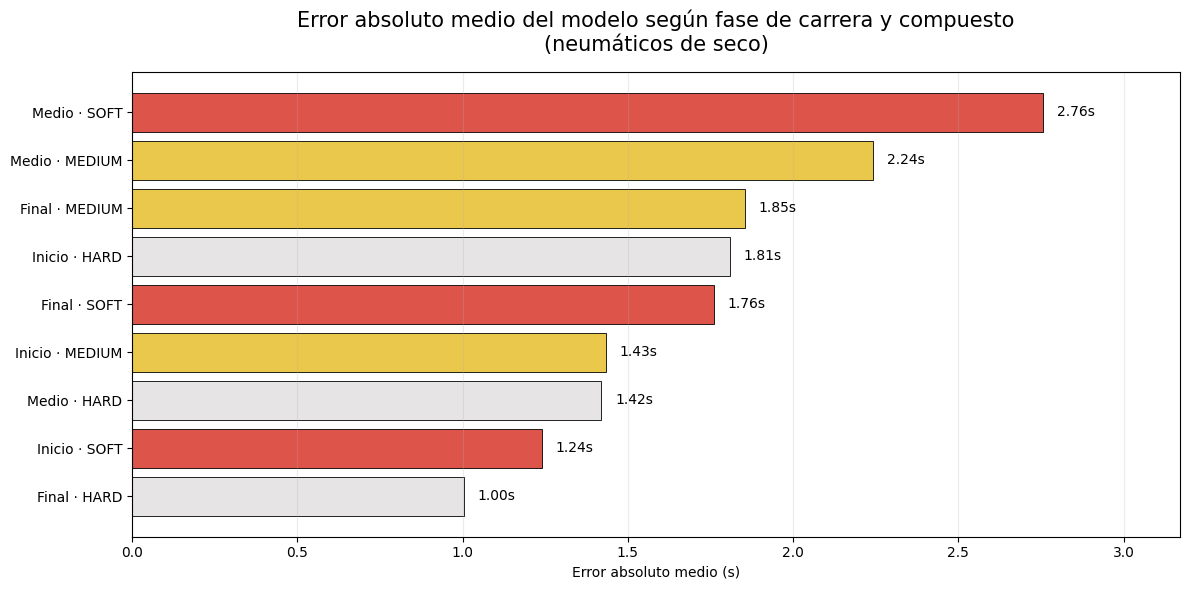

In [68]:
#Error del modelo según fase de la carrera y compuesto

plot_error = error_phase_compound.query("Compound in ['SOFT', 'MEDIUM', 'HARD']").copy()
plot_error["Label"] = plot_error["RacePhase"].astype(str) + " · " + plot_error["Compound"].astype(str)
plot_error = plot_error.sort_values("MAE", ascending=False).reset_index(drop=True)

compound_colors = {"SOFT": "#dd544b", "MEDIUM": "#eac84b", "HARD": "#e6e4e4"}
colors = plot_error["Compound"].astype(str).map(compound_colors).fillna("gray")

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(plot_error["Label"], plot_error["MAE"], color=colors, edgecolor="black", linewidth=0.6)

ax.invert_yaxis()
max_mae = plot_error["MAE"].max()
ax.set_xlim(0, max_mae * 1.15)

for bar in bars:
    width = bar.get_width()
    ax.text(width + max_mae * 0.015, bar.get_y() + bar.get_height()/2, f"{width:.2f}s", va="center", fontsize=10)

ax.set_title("Error absoluto medio del modelo según fase de carrera y compuesto\n(neumáticos de seco)", fontsize=15, pad=15)
ax.set_xlabel("Error absoluto medio (s)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

##### Error según la antigüedad del neumático

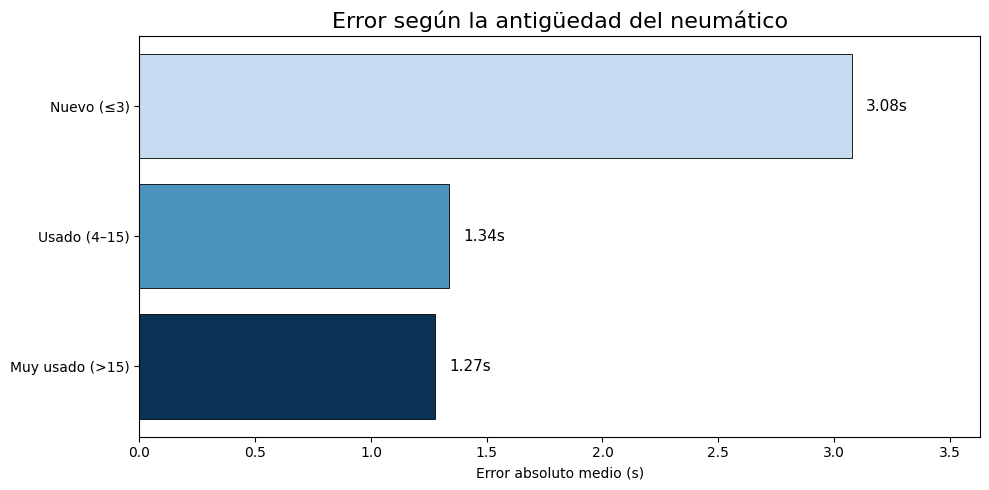

,TyreAge,MAE,N
0,Nuevo (≤3),3.0770,2277
1,Usado (4–15),1.3364,11113
2,Muy usado (>15),1.2748,9800


In [69]:
#Error según la antigüedad del neumático

temp = error_analysis_df[error_analysis_df["Compound"].isin(["SOFT", "MEDIUM", "HARD"])].copy()
temp["TyreAge"] = np.where(temp["TyreLife"] <= 3, "Nuevo (≤3)", np.where(temp["TyreLife"] <= 15, "Usado (4–15)", "Muy usado (>15)"))

tyre_error = temp.groupby("TyreAge").agg(MAE=("Absolute_Error", "mean"), N=("Absolute_Error", "count")).reset_index()
orden = ["Nuevo (≤3)", "Usado (4–15)", "Muy usado (>15)"]
tyre_error["TyreAge"] = pd.Categorical(tyre_error["TyreAge"], categories=orden, ordered=True)
plot_data = tyre_error.sort_values("TyreAge")

tyre_age_colors = {"Nuevo (≤3)": "#c6dbef", "Usado (4–15)": "#4b92bc", "Muy usado (>15)": "#0a3254"}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(plot_data["TyreAge"].astype(str), plot_data["MAE"], color=plot_data["TyreAge"].astype(str).map(tyre_age_colors), edgecolor="black", linewidth=0.6)

ax.invert_yaxis()
max_val = plot_data["MAE"].max()
ax.set_xlim(0, max_val * 1.18)

for bar, value in zip(bars, plot_data["MAE"]):
    ax.text(value + max_val * 0.02, bar.get_y() + bar.get_height()/2, f"{value:.2f}s", va="center", ha="left", fontsize=11)

ax.set_title("Error según la antigüedad del neumático", fontsize=16)
ax.set_xlabel("Error absoluto medio (s)")
plt.tight_layout()
plt.show()

display(tyre_error.sort_values("TyreAge").reset_index(drop=True).round(4))

##### Error en vueltas de inicio de stint

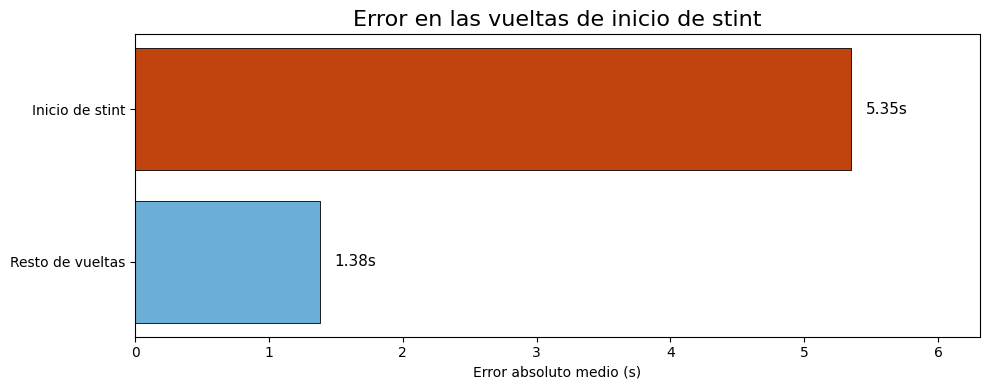

,StintChange,MAE,N
0,Inicio de stint,5.3509,591
1,Resto de vueltas,1.3801,22599


In [70]:
#Error en vueltas de inicio de stint

temp = error_analysis_df[error_analysis_df["Compound"].isin(["SOFT", "MEDIUM", "HARD"])].copy()
temp["StintChange"] = np.where(temp["StintStart"], "Inicio de stint", "Resto de vueltas")

stint_error = temp.groupby("StintChange").agg(MAE=("Absolute_Error", "mean"), N=("Absolute_Error", "count")).reset_index()
orden = ["Inicio de stint", "Resto de vueltas"]
stint_error["StintChange"] = pd.Categorical(stint_error["StintChange"], categories=orden, ordered=True)
plot_data = stint_error.sort_values("StintChange")

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(plot_data["StintChange"].astype(str), plot_data["MAE"], color=["#c1440e", "#6baed6"], edgecolor="black", linewidth=0.6)
ax.invert_yaxis()
max_val = plot_data["MAE"].max()
ax.set_xlim(0, max_val * 1.18)

for bar, value in zip(bars, plot_data["MAE"]):
    ax.text(value + max_val * 0.02, bar.get_y() + bar.get_height()/2, f"{value:.2f}s", va="center", ha="left", fontsize=11)

ax.set_title("Error en las vueltas de inicio de stint", fontsize=16)
ax.set_xlabel("Error absoluto medio (s)")
plt.tight_layout()
plt.show()
display(plot_data.reset_index(drop=True).round(4))

##### Error del modelo global según el piloto

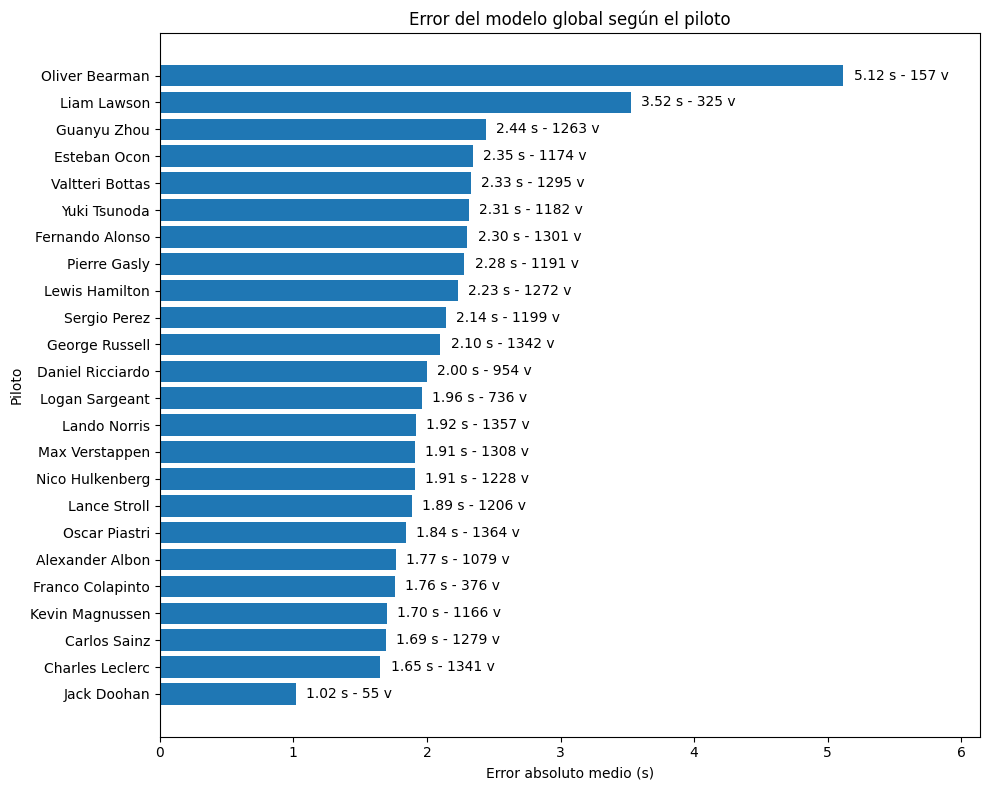

,Driver,MAE,N
0,Oliver Bearman,5.117,157
1,Liam Lawson,3.524,325
2,Guanyu Zhou,2.443,1263
3,Esteban Ocon,2.345,1174
4,Valtteri Bottas,2.329,1295
5,Yuki Tsunoda,2.313,1182
6,Fernando Alonso,2.302,1301
7,Pierre Gasly,2.281,1191
8,Lewis Hamilton,2.230,1272
9,Sergio Perez,2.144,1199


In [71]:
#Error del modelo global según el piloto

driver_error = error_analysis_df.groupby("Driver").agg(MAE=("Absolute_Error", "mean"), N=("Absolute_Error", "count")).reset_index().sort_values("MAE", ascending=False)
driver_error["Driver"] = driver_error["Driver"].map(driver_names).fillna(driver_error["Driver"])

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(driver_error["Driver"], driver_error["MAE"])

ax.invert_yaxis()
ax.set_xlim(0, driver_error["MAE"].max() * 1.20)

for bar, n in zip(bars, driver_error["N"]):
    ax.text(bar.get_width() + driver_error["MAE"].max() * 0.015, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.2f} s - {n} v", va="center", fontsize=10)

ax.set_title("Error del modelo global según el piloto")
ax.set_xlabel("Error absoluto medio (s)")
ax.set_ylabel("Piloto")

plt.tight_layout()
plt.show()

display(driver_error.reset_index(drop=True).round(3))

##### Error del modelo global según el gran premio

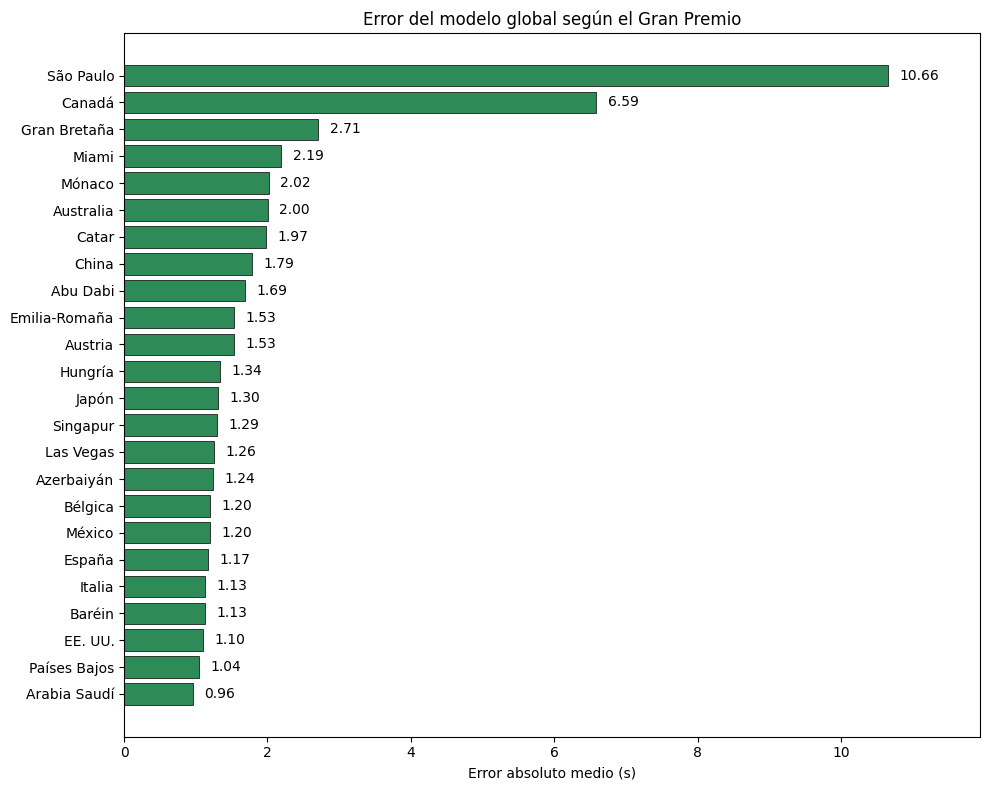

,GP,MAE,N
0,São Paulo,10.659703,998
1,Canadá,6.588992,1121
2,Gran Bretaña,2.707865,913
3,Miami,2.191279,1048
4,Mónaco,2.021350,1200
5,Australia,2.000333,957
6,Catar,1.974240,755
7,China,1.788069,854
8,Abu Dabi,1.687547,1001
9,Emilia-Romaña,1.530701,1215


In [72]:
#Error del modelo global según el gran premio

gp_error = error_analysis_df.groupby("GP_file").agg(MAE=("Absolute_Error", "mean"), N=("Absolute_Error", "count")).reset_index().sort_values("MAE", ascending=False)
gp_error["GP"] = gp_error["GP_file"].replace(gp_labels_val)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(gp_error["GP"], gp_error["MAE"], color="#2e8b57", edgecolor="black", linewidth=0.5)

ax.invert_yaxis()
max_val = gp_error["MAE"].max()
ax.set_xlim(0, max_val * 1.12)

for bar in bars:
    w = bar.get_width()
    ax.text(w + max_val * 0.015, bar.get_y() + bar.get_height()/2, f"{w:.2f}", va="center", fontsize=10)

ax.set_title("Error del modelo global según el Gran Premio")
ax.set_xlabel("Error absoluto medio (s)")
plt.tight_layout()
plt.show()

display(gp_error[["GP", "MAE", "N"]].reset_index(drop=True))

## Versiones utilizadas

In [73]:
print("Python:", sys.version.split()[0])

for package in ["pandas", "numpy", "scikit-learn", "matplotlib", "ipykernel", "notebook", "fastf1"]:
    try:
        print(f"{package}: {version(package)}")
    except PackageNotFoundError:
        print(f"{package}: no consta como paquete instalado")

Python: 3.11.14
pandas: 2.3.3
numpy: 2.4.2
scikit-learn: 1.8.0
matplotlib: 3.10.8
ipykernel: 7.2.0
notebook: 7.5.4
fastf1: 3.8.3
